# Charge-trap paper figures

Driver notebook for the SENSEI charge-trap figures. All reusable logic lives in
[`figure_utils.py`](figure_utils.py); this notebook only sets the toggles in §0 and
calls the helpers. Three data sources are switchable from the config block below:
the trap-fit catalog (`FIT_SOURCE`), the Method-3 completeness version
(`METHOD3_VERSION` / `METHOD3_VARIANT`), and the simulation campaign scenarios
(§5). Dead/duplicate/exploratory cells were moved to the **Archive** section at the
end — nothing was deleted.


## 0. Config & setup

In [1]:
from figure_utils import *
import figure_utils as fu
import os

setup_style()

# ---- Pipeline toggle: switch every input file between the legacy and minimal runs ----
PIPELINE  = 'minimal'      # 'legacy' (dipole.py)  or  'minimal' (dipole_new.py, physical errors)
DETECTION = 'calibrated'       # minimal only: 'fixed' or 'calibrated' (adds a _caldet tag)

_suffix  = '_minimal' if PIPELINE == 'minimal' else ''
_det_tag = '_caldet' if (PIPELINE == 'minimal' and DETECTION == 'calibrated') else ''

# Derived input filenames (mirror run_charge_traps.py naming exactly).
COORD_FILE     = f'dipole_coord_list{_suffix}.npz'
MC_FILE        = f'mc_dist{_suffix}.npz'
DIPOLE_SPECTRA = f'dipole_spectra{_suffix}.h5'
FIT_SOURCE     = f'fit_dipole_spectra{_suffix}{_det_tag}_err_4.h5'   # _err = useIntensityErr, _4 = threshold

# ---- Display / analysis toggles ----
# Error bars drawn in the example-trap plots. NOT a model switch: the error model
# is baked into the catalog at fit time (see run_charge_traps.py --pipeline).
#   'intensity_err' : the error the fit used (physical temporal noise under
#                     minimal; patch spatial sigma under legacy)
#   'patch_sigma'   : legacy 34x34 patch spatial sigma (minimal catalogs only)
#   'poisson_err'   : sqrt(|patch mean|) Poisson estimate
ERR_FIELD        = 'intensity_err'

METHOD3_VERSION  = 'v1'                             # Method-3 completeness artifact version
METHOD3_VARIANT  = 'default'                        # 'default' or 'tau1000'

CAMPAIGN_BASE    = 'campaign'                       # root of run_campaign.py output dirs
WRITE_SEED_FILES = False                            # gate tau_at_*k_hist.npz / upper-limit npz writes

# Show what each input toggle resolved to and whether it exists on disk.
# Route figure saves to figures/ (minimal) or figures_legacy/ (legacy).
fu.use_flavor(PIPELINE)

print(f"PIPELINE={PIPELINE!r}  DETECTION={DETECTION!r}")
for _name in ('COORD_FILE', 'MC_FILE', 'DIPOLE_SPECTRA', 'FIT_SOURCE'):
    _f = globals()[_name]
    print(f"  {_name:14} = {_f:42} {'OK' if os.path.exists(_f) else 'MISSING'}")


PIPELINE='minimal'  DETECTION='calibrated'
  COORD_FILE     = dipole_coord_list_minimal.npz              OK
  MC_FILE        = mc_dist_minimal.npz                        OK
  DIPOLE_SPECTRA = dipole_spectra_minimal.h5                  OK
  FIT_SOURCE     = fit_dipole_spectra_minimal_caldet_err_4.h5 OK


In [ ]:
from dipole_new import log_energy_cross_section

E1 = 0.3
E2 = 0.6
sigma1 = np.log(1e-15)
sigma2 = np.log(1e-15)
temperatures = np.linspace(125, 210, 20)

taus_1 = np.exp(log_energy_cross_section(temperatures, E1, logsigma=sigma1))
taus_2 = np.exp(log_energy_cross_section(temperatures, E2, logsigma=sigma2))

plt.figure(figsize=(12,8))
plt.axhline(1,label='Approx. Measurement Threshold',color='grey')
plt.axvline(135,label='Operating Temperature',color='steelblue')
plt.yscale('log')

plt.plot(
    temperatures,
    taus_1,
    label=fr'Caught Trap: $E = {E1:.1f}\,\mathrm{{eV}},\ \sigma = {np.exp(sigma1):.1e}$',
    color='black'
)

plt.plot(
    temperatures,
    taus_2,
    label=fr'Missed Trap: $E = {E2:.1f}\,\mathrm{{eV}},\ \sigma = {np.exp(sigma2):.1e}$',
    color='red'
)

plt.ylabel(r"$\tau_e$ [s]")
plt.xlabel("Temperature [K]")
# plt.xlim(125, 220)
plt.legend()
plt.show()
plt.close()

## 1. Data loading
Dipole coordinates, the Monte-Carlo null distance distribution, the per-dipole
spectra, and the trap-fit catalog selected by `FIT_SOURCE`.

In [ ]:
image_dir_search = 'proc/*.fits'
temperatures = []
for image in glob.glob(image_dir_search):
    # Using a raw string r'' to fix the \d escape sequence warning
    found = re.findall(r'_\d+k', image)
    if not found:
        continue
    temp = found[0][1:-1]
    
    if 'dtph' not in image:
        continue
        
    temperatures.append(temp)
    
temperatures_strs = np.array(temperatures)

temps = np.sort(np.array([int(t) for t in temperatures_strs]))
test_temps = np.unique(temps)
print("Unique temperatures:", test_temps)
good_quads=[0, 1, 2, 3]
try:
    coords_npz = np.load(COORD_FILE)
    full_dipole_coord_list = []
    for i in range(len(good_quads)):
        if f'quad_idx_{i}' in coords_npz:
            full_dipole_coord_list.append([tuple(c) for c in coords_npz[f'quad_idx_{i}']])
        else:
            full_dipole_coord_list.append([])
    print(f"Loaded {COORD_FILE}")
except FileNotFoundError:
    print(f"{COORD_FILE} not found. Computing...")

# Calculate total dipoles across valid quadrants
total = sum(len(full_dipole_coord_list[q]) for q in good_quads)
total = sum(len(q_list) for q_list in full_dipole_coord_list)
print(f"Total dipoles: {total}")

In [ ]:
try:
    mcdict = np.load(MC_FILE, allow_pickle=True)
    montecarlo_hists = mcdict['montecarlo_hists']
    mc_bin_centers = mcdict['mc_bin_centers']
    mc_mean = mcdict['mc_mean']
    ci_lower = mcdict['ci_lower']
    ci_upper = mcdict['ci_upper']
    print(f"Loaded {MC_FILE}")
except FileNotFoundError:
    print(f"{MC_FILE} not found.")

In [ ]:
try:
    dipole_spectra = load_spectra_hdf5(DIPOLE_SPECTRA)
    print(f"Loaded {DIPOLE_SPECTRA}")
except FileNotFoundError:
    print("dipole_spectra.h5 not found. Please compute with run_charge_traps...")

In [ ]:
fit_dipole_spectra = load_trap_fits(FIT_SOURCE)

### 1.1 Spatial distribution vs Monte-Carlo null

In [ ]:
plot_spatial_distribution(full_dipole_coord_list, mc_bin_centers, mc_mean,
                          ci_lower, ci_upper)

## 2. Trap fits
Aggregate the catalog into the per-trap (τ, E, σ) arrays, then the characterized-trap
figure, the energy/cross-section histograms, example traps, and amplitude-vs-temperature.

In [ ]:
agg = aggregate_trap_fits(fit_dipole_spectra)
energy_crossSections = agg['energy_crossSections']
tau_temp_fits        = agg['tau_temp_fits']
tau_temperatures     = agg['tau_temperatures']
cross_sections       = agg['cross_sections']
energies             = agg['energies']

In [ ]:
# plot_characterized_traps(agg)
# plot_characterized_traps(agg,show_cov_ellipses=True, show_tau_band=False)
plot_characterized_traps(agg,show_cov_ellipses=True, show_tau_band=True)


In [ ]:
plot_energy_sigma_hists(agg)

In [ ]:
plot_energy_sigma_hist2d(agg)

In [ ]:
plot_example_traps(fit_dipole_spectra, err_field=ERR_FIELD, max_plots=5)


In [ ]:
plot_amplitude_vs_temperature(fit_dipole_spectra, num_traps_to_plot=500)

## 3. Completeness (Method 3)
Load the versioned Method-3 detection model, overlay it on the τ histogram, and
derive the efficiency-corrected 90% CL upper-limit population. The upper-limit NPZ is
written only when `WRITE_SEED_FILES` is on.

In [2]:
m3 = load_method3(version=METHOD3_VERSION, variant=METHOD3_VARIANT,pipeline=PIPELINE, detection=DETECTION)

Applied energy-fit survival 0.972 to the 'characterized' completeness maps/curves (intensity maps stay raw).
Stage 10 produced at: 2026-06-18T14:47:26-07:00
Thermal model source: dipole.log_energy_cross_section
Histogram source: tau_at_135k_hist_minimal_caldet.npz
Trap count in histogram bins: 3798


Saved: figures\efficiency_completeness.pdf


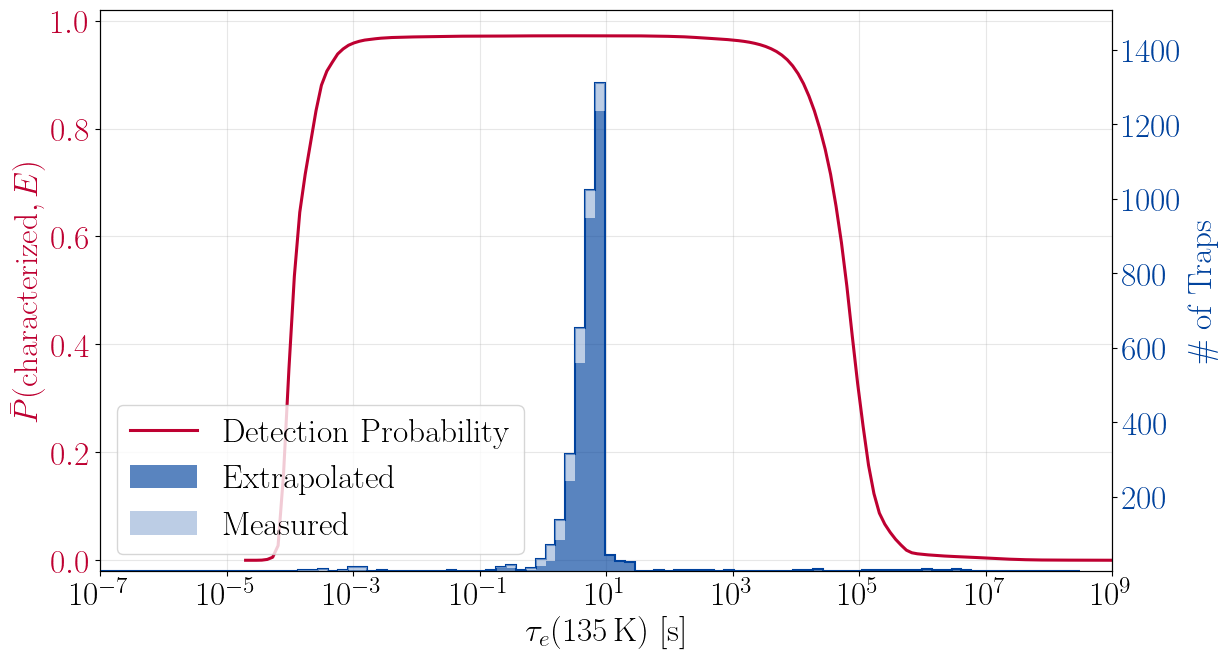

In [3]:
plot_completeness_overlay(m3)

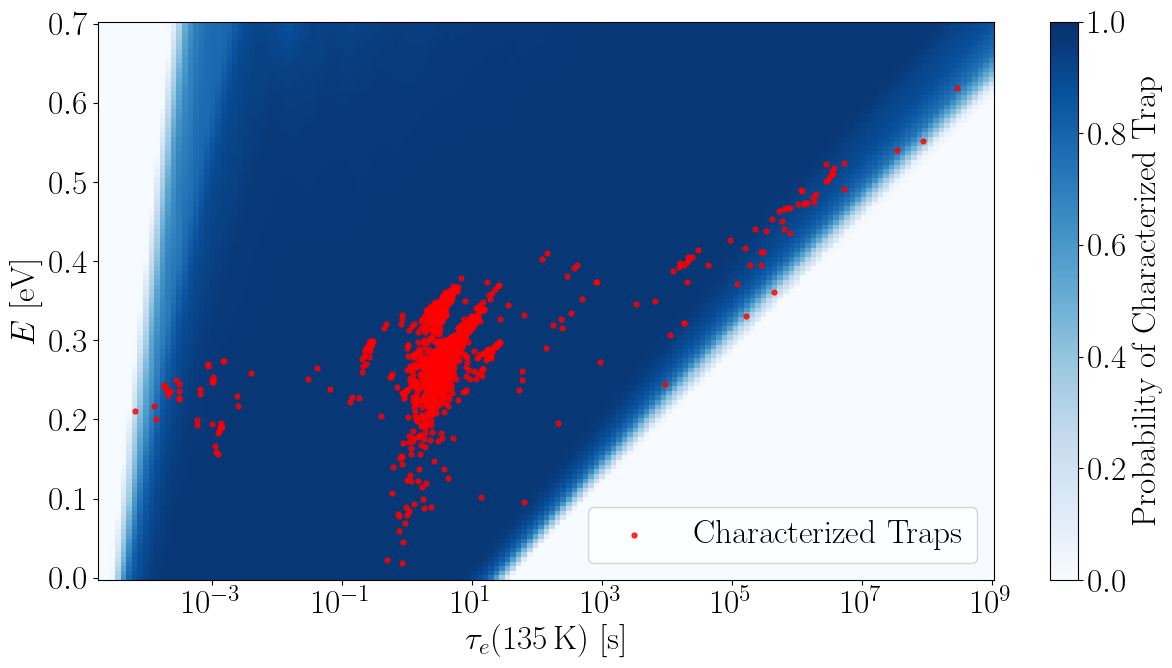

Unbounded grid fraction: 0.21087213182074843
E range: 0.0 to 0.5483333333333332 eV
tau_135 range: 52.77426399132851 to 1000000000.0 s
max P4 in unbounded regime: 0.0


In [4]:
plot_completeness_map(m3)

In [ ]:
# Characterized traps colored by the temperature where they were actually caught.
# tau_e(135 K) is an extrapolation for long-tau / high-E traps: those were detected
# at high T (in window), not at 135 K -- so the apparent low-probability right arm
# was in fact measured in high-probability regions. Separate from plot_completeness_map
# (the plain red overlay), which is unchanged. color_scalar: 'mean' (default)|'median'|'max'.
for _flavor in ('legacy', 'minimal_caldet'):
    _m3 = load_method3(version=METHOD3_VERSION, variant=METHOD3_VARIANT,
                       analysis_flavor=_flavor)
    plot_completeness_map_caught_at_T(_m3, color_scalar='mean')

In [ ]:
plot_tau135_energy_scatter(m3)

Excluded 23 bins with completeness below 0% or outside the model grid.
Excluded 18 bins with completeness below 0% or outside the model grid.
Saved: figures\tau_at_135k_hist_efficiency_combined.pdf


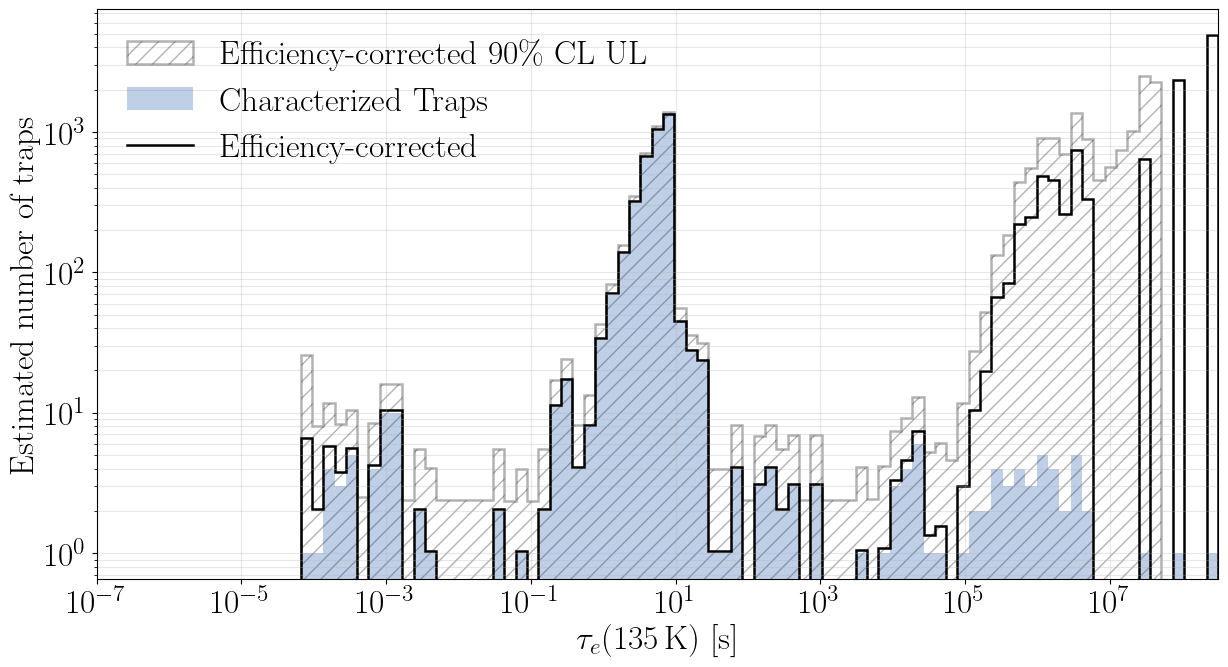

{'point_estimate': array([0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 6.60490830e+00, 2.05571028e+00,
        5.82469006e+00, 3.75558225e+00, 5.63754129e+00, 0.00000000e+00,
        4.22522625e+00, 1.04429888e+01, 1.03838235e+01, 0.00000000e+00,
        2.06684866e+00, 1.03225820e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 2.05957769e+00,
        0.00000000e+00, 1.02962550e+00, 0.00000000e+00, 2.05902053e+00,
        1.13235828e+01, 1.74971954e+01, 4.11641993e+00, 8.23217933e+00,
        3.39552848e+01, 7.09944483e+01, 1.39928592e+02, 3.23070402e+02,
        6.72896065e+02, 1.05256203e+03, 1.34889484e+03, 4.52721351e+01,
        2.77811909e+01, 2.36662365e+01, 1.0290

In [25]:
plot_efficiency_correction_combined(m3, confidence_level=0.90, min_efficiency=0.0, correction_tau_min=6e-5, ul_tau_max=5e7, point_tau_max=1e9, save=True)

In [ ]:
# The upper-limit seed is written to a flavor-derived name
# (m3['paths']['tau_hist_upper_npz']) so it always matches the Method-3
# completeness model that produced it. WRITE_SEED_FILES gates the write.
corrected_tau_hist = plot_upper_limit_hist(m3, write=True,correction_tau_min=6e-5,correction_tau_max=5e7)

In [ ]:
# Efficiency-corrected (completeness point-estimate) seed for the trap-only
# (zero dark-current) campaign. Same flavor-derived naming + tau range as the
# upper-limit seed above, but WITHOUT the 90% CL Poisson inflation.
corrected_eff_hist = plot_efficiency_corrected_hist(m3, write=True, correction_tau_min=6e-5, correction_tau_max=1e9)

## 4. τ histograms by temperature
Per-temperature measured/extrapolated τ histograms. Figures always render; the
`tau_at_<T>k_hist.npz` seed files are written only when `WRITE_SEED_FILES` is on
(the 135 K seed is also produced by `run_charge_traps.py`).

In [ ]:
plot_tau_hist_single(tau_temperatures, t=135,log=True)

In [ ]:
# plot_tau_histograms_by_temperature(tau_temperatures, write_seed=WRITE_SEED_FILES)

## 5. Simulation
Campaign scenarios resolve to `campaign/<label>/` via `scenario_dir(...)` (reusing
`run_campaign.label_for`); legacy flat dirs are available through `LEGACY_SCENARIOS`.
`compare_scenarios` overlays any set of scenarios on the forest plot.

In [10]:
MASK = 'Halo+Bleed+HotColumn+HotPixel'
sim_pipe = PIPELINE + '_caldet'
# sim_pipe= 'legacy'
# Pick scenarios to compare. Each entry is (display label, run directory).
# Campaign axes: condition='minos'|'snolab', population='baseline'|'upper',
#                vp=1|3|10, clear='sequencer'|'three_hour'|'binned_0h',
#                order='shuffled'|'ordered'.

exp_indep = 'pre_readout' # 'pre_readout' or 'post_readout'
event_type = '1e'

clear = 'three_hour'
# clear = 'sequencer'
if clear == 'three_hour':
    clear_str = '3h Clear Seq'

elif clear == 'sequencer':
    clear_str = 'Clear Seq'

elif clear == 'binned_0h':
    clear_str = '0h bin Seq'

vp = 1
binning = 32
kwargs = {
    'order' : 'shuffled',
    'exp_indep': exp_indep,
    'population':'baseline',
    'base' : CAMPAIGN_BASE,
    'flavor':sim_pipe,
    'vp': vp,
    # 'clear': clear
    
}
kwargs_upper = {
    'order' : 'shuffled',
    'exp_indep': exp_indep,
    'population':'upper',
    'base' : CAMPAIGN_BASE,
    'flavor':sim_pipe,
    'vp': vp,
    # 'clear': clear
}

kwargs_eff = {
    'order' : 'shuffled',
    'exp_indep': exp_indep,
    'population':'effcorr',
    'base' : CAMPAIGN_BASE,
    'flavor':sim_pipe,
    'vp': vp,
    # 'clear': clear
}

zero_exp_dep = False
def spec(cond, **over):
    # return dict(condition=cond, systematics=('vp',), **{**kwargs, **over})
    return dict(condition=cond, **{**kwargs, **over})


scenarios = [
    ('MINOS clear seq',         spec('minos',  clear='sequencer',**kwargs)),
    ('MINOS 3h Clear seq',      spec('minos',  clear='three_hour',**kwargs)),
    ('MINOS 0h bin clear',      spec('minos',  clear='binned_0h',**kwargs)),
    ('MINOS binned clear seq',  spec('minos',  clear='sequencer', binning=32,**kwargs)),
    # ('MINOS UL 3h Clear seq',      spec('minos',  clear='three_hour',**kwargs_upper)),

    ('SNOLAB clear seq',        spec('snolab', clear='sequencer',**kwargs)),
    ('SNOLAB 3h clear seq',     spec('snolab', clear='three_hour',**kwargs)),
    ('SNOLAB 0h bin clear',     spec('snolab', clear='binned_0h',**kwargs)),
    ('SNOLAB binned clear seq', spec('snolab', clear='sequencer', binning=32,**kwargs)),
    # ('SNOLAB UL 3h Clear seq',      spec('snolab',  clear='three_hour',**kwargs_upper)),

]


scenarios_simple = [
    # ('MINOS clear seq',         spec('minos',  clear='sequencer',**kwargs)),
    ('MINOS 3h Clear',      scenario_dir('minos',  clear='three_hour',**kwargs)),
    # ('MINOS 0h bin clear',      spec('minos',  clear='binned_0h',**kwargs)),
    ('MINOS binned 3h Clear',  scenario_dir('minos',  clear='three_hour', binning=32,**kwargs)),
    # ('MINOS UL 3h Clear seq',      spec('minos',  clear='three_hour',**kwargs_upper)),

    # ('SNOLAB clear seq',        spec('snolab', clear='sequencer',**kwargs)),
    ('SNOLAB 3h Clear',     scenario_dir('snolab', clear='three_hour',**kwargs)),
    # ('SNOLAB 0h bin clear',     spec('snolab', clear='binned_0h',**kwargs)),
    ('SNOLAB binned 3h Clear',  scenario_dir('snolab',  clear='three_hour', binning=32,**kwargs)),
    # ('SNOLAB UL 3h Clear seq',      spec('snolab',  clear='three_hour',**kwargs_upper)),

]


# scenarios_simple = [
#     # ('MINOS clear seq',         spec('minos',  clear='sequencer',**kwargs)),
#     ('MINOS 3h Clear',      spec('minos',  clear='three_hour',**kwargs)),
#     # ('MINOS 0h bin clear',      spec('minos',  clear='binned_0h',**kwargs)),
#     ('MINOS binned 3h Clear',  spec('minos',  clear='three_hour', binning=32,**kwargs)),
#     # ('MINOS UL 3h Clear seq',      spec('minos',  clear='three_hour',**kwargs_upper)),

#     # ('SNOLAB clear seq',        spec('snolab', clear='sequencer',**kwargs)),
#     ('SNOLAB 3h Clear',     spec('snolab', clear='three_hour',**kwargs)),
#     # ('SNOLAB 0h bin clear',     spec('snolab', clear='binned_0h',**kwargs)),
#     ('SNOLAB binned 3h Clear',  spec('snolab',  clear='three_hour', binning=32,**kwargs)),
#     # ('SNOLAB UL 3h Clear seq',      spec('snolab',  clear='three_hour',**kwargs_upper)),

# ]



scenarios_upper = [
    # ('MINOS clear seq',         spec('minos',  clear='sequencer',**kwargs)),
    ('MINOS 3h Clear seq',      spec('minos',  clear='three_hour',**kwargs)),
    # ('MINOS 0h bin clear',      spec('minos',  clear='binned_0h',**kwargs)),
    # ('MINOS binned clear seq',  spec('minos',  clear='sequencer', binning=32,**kwargs)),
    ('MINOS UL 3h Clear seq',      spec('minos',  clear='three_hour',**kwargs_upper)),

    # ('SNOLAB clear seq',        spec('snolab', clear='sequencer',**kwargs)),
    ('SNOLAB 3h clear seq',     spec('snolab', clear='three_hour',**kwargs)),
    # ('SNOLAB 0h bin clear',     spec('snolab', clear='binned_0h',**kwargs)),
    # ('SNOLAB binned clear seq', spec('snolab', clear='sequencer', binning=32,**kwargs)),
    ('SNOLAB UL 3h Clear seq',      spec('snolab',  clear='three_hour',**kwargs_upper)),


    # ('MINOS clear seq vp1',  scenario_dir('minos',  vp=1,clear='sequencer',**kwargs)),
    # ('MINOS clear seq vp3',  scenario_dir('minos',  vp=3,clear='sequencer',**kwargs)),
    # ('MINOS clear seq vp10',  scenario_dir('minos',  vp=10,clear='sequencer',**kwargs)),


    # (f'MINOS {clear_str}',  scenario_dir('snolab',zero_exp_dep=zero_exp_dep,**kwargs)),
    # (f'SNOLAB {clear_str}',  scenario_dir('snolab',zero_exp_dep=zero_exp_dep,**kwargs)),


    # (f'MINOS UL {clear_str}',  scenario_dir('snolab',zero_exp_dep=zero_exp_dep,**kwargs_upper)),
    # (f'SNOLAB UL {clear_str}',  scenario_dir('snolab',zero_exp_dep=zero_exp_dep,**kwargs_upper)),

    # (f'MINOS UL binned {clear_str}',  scenario_dir('snolab',zero_exp_dep=zero_exp_dep,binning=binning,**kwargs_upper)),
    # (f'SNOLAB {clear_str}',  scenario_dir('snolab',zero_exp_dep=False,binning=binning,**kwargs)),
    # # (f'SNOLAB Eff. Corr. {clear_str}',  scenario_dir('snolab',zero_exp_dep=False,binning=binning,**kwargs_eff)),
    # (f'SNOLAB UL {clear_str}',  scenario_dir('snolab',zero_exp_dep=False,binning=binning,**kwargs_upper)),

    # #  (f'SNOLAB {clear_str}',  scenario_dir('snolab',zero_exp_dep=True,binning=binning,**kwargs)),
    # (f'SNOLAB Eff. Corr. Zero ExpDep {clear_str}',  scenario_dir('snolab',zero_exp_dep=True,binning=binning,**kwargs_eff)),
    # (f'SNOLAB UL Zero ExpDep {clear_str}',  scenario_dir('snolab',zero_exp_dep=True,binning=binning,**kwargs_upper)),

    # ('MINOS UL 3h clear',  scenario_dir('minos',  clear='three_hour',**kwargs_upper)),
    # ('SNOLAB UL clear seq',  scenario_dir('snolab',  clear='sequencer',**kwargs_upper)),

    # ('SNOLAB UL clear seq',  scenario_dir('snolab',  clear='sequencer',**kwargs_upper)),

    # Readout-binning 32x variants (run_campaign --binning-factors 32). Only
    # emitted for the standard sequencer clear at the central V_p in shuffled
    # order; pass binning=32 to scenario_dir to resolve the _bin32 dirs.
    # ('MINOS clear seq bin32',  scenario_dir('minos',  population='baseline', base=CAMPAIGN_BASE, clear='sequencer',order=order,flavor=sim_pipe,exp_indep=exp_indep,binning=32)),
    # ('MINOS UL clear seq bin32',  scenario_dir('minos',  population='upper', base=CAMPAIGN_BASE, clear='sequencer',order=order,flavor=sim_pipe,exp_indep=exp_indep,binning=32)),
    # ('SNOLAB clear seq bin32',  scenario_dir('snolab',  population='baseline', base=CAMPAIGN_BASE, clear='sequencer',order=order,flavor=sim_pipe,exp_indep=exp_indep,binning=32)),
    # ('SNOLAB UL clear seq bin32',  scenario_dir('snolab',  population='upper', base=CAMPAIGN_BASE, clear='sequencer',order=order,flavor=sim_pipe,exp_indep=exp_indep,binning=32)),

    # ('MINOS 3h Clear',  scenario_dir('minos',  population='baseline', base=CAMPAIGN_BASE, clear='three_hour',order=order,flavor=sim_pipe,exp_indep=exp_indep)),
    # ('SNOLAB 3h Clear',  scenario_dir('snolab',  population='baseline', base=CAMPAIGN_BASE, clear='three_hour',order=order,flavor=sim_pipe,exp_indep=exp_indep)),
    # ('MINOS UL 3h Clear',  scenario_dir('minos',  population='upper', base=CAMPAIGN_BASE, clear='three_hour',order=order,flavor=sim_pipe,exp_indep=exp_indep)),
    # ('SNOLAB UL 3h Clear',  scenario_dir('snolab',  population='upper', base=CAMPAIGN_BASE, clear='three_hour',order=order,flavor=sim_pipe,exp_indep=exp_indep)),

    # ('MINOS 0h Binned',  scenario_dir('minos',  population='baseline', base=CAMPAIGN_BASE, clear='binned_0h',order=order,flavor=sim_pipe,exp_indep=exp_indep)),
    # ('SNOLAB 0h Binned',  scenario_dir('snolab',  population='baseline', base=CAMPAIGN_BASE, clear='binned_0h',order=order,flavor=sim_pipe,exp_indep=exp_indep)),
    # ('MINOS UL 0h Binned',  scenario_dir('minos',  population='upper', base=CAMPAIGN_BASE, clear='binned_0h',order=order,flavor=sim_pipe,exp_indep=exp_indep)),
    # ('SNOLAB UL 0h Binned',  scenario_dir('snolab',  population='upper', base=CAMPAIGN_BASE, clear='binned_0h',order=order,flavor=sim_pipe,exp_indep=exp_indep)),

    # ('MINOS upper',     scenario_dir('minos',  population='upper',    base=CAMPAIGN_BASE)),
    # ('SNOLAB baseline', scenario_dir('snolab', population='baseline', base=CAMPAIGN_BASE)),
    # ('SNOLAB upper',    scenario_dir('snolab', population='upper',    base=CAMPAIGN_BASE)),
]
# Legacy flat dirs (pre-campaign outputs) can be mixed in, e.g.:
# scenarios = [('MINOS (legacy)', LEGACY_SCENARIOS['minos']),
#              ('SNOLAB (legacy)', LEGACY_SCENARIOS['snolab'])]
for label, d in scenarios:
    print(f'{label:<18} -> {d}')

MINOS clear seq    -> {'condition': 'minos', 'order': 'shuffled', 'exp_indep': 'pre_readout', 'population': 'baseline', 'base': 'campaign', 'flavor': 'minimal_caldet', 'vp': 1, 'clear': 'sequencer'}
MINOS 3h Clear seq -> {'condition': 'minos', 'order': 'shuffled', 'exp_indep': 'pre_readout', 'population': 'baseline', 'base': 'campaign', 'flavor': 'minimal_caldet', 'vp': 1, 'clear': 'three_hour'}
MINOS 0h bin clear -> {'condition': 'minos', 'order': 'shuffled', 'exp_indep': 'pre_readout', 'population': 'baseline', 'base': 'campaign', 'flavor': 'minimal_caldet', 'vp': 1, 'clear': 'binned_0h'}
MINOS binned clear seq -> {'condition': 'minos', 'order': 'shuffled', 'exp_indep': 'pre_readout', 'population': 'baseline', 'base': 'campaign', 'flavor': 'minimal_caldet', 'vp': 1, 'clear': 'sequencer', 'binning': 32}
SNOLAB clear seq   -> {'condition': 'snolab', 'order': 'shuffled', 'exp_indep': 'pre_readout', 'population': 'baseline', 'base': 'campaign', 'flavor': 'minimal_caldet', 'vp': 1, 'clear

### 5.1 Single-scenario detail

In [7]:
# # Detailed exposure-vs-density fit for one scenario.


for i in range((len(scenarios))):
    print(scenarios[i][0])
    # try:
    # plot_simulation_results(scenarios[i][1], mask=MASK, showDensity=False,event_type=event_type,showFit=True)
    # except FileNotFoundError:
    #     continue                         
# ul_present = False
# for s in scenarios:
#     print(s[0].lower())
#     if 'ul' in s[0].lower(): ul_present=True

# ul_present

MINOS clear seq
MINOS 3h Clear seq
MINOS 0h bin clear
MINOS binned clear seq
SNOLAB clear seq
SNOLAB 3h clear seq
SNOLAB 0h bin clear
SNOLAB binned clear seq


### 5.2 Scenario comparison (forest plot)

campaign\minos_baseline_vp1_expind_pre_clear3h_shuf_minimal_caldet\aggregated_results_Halo+Bleed+HotColumn+HotPixel_1e.json
Loading JSON cached aggregated 1e data from campaign\minos_baseline_vp1_expind_pre_clear3h_shuf_minimal_caldet\aggregated_results_Halo+Bleed+HotColumn+HotPixel_1e.json...
campaign\minos_baseline_vp1_expind_pre_clear3h_shuf_bin32_minimal_caldet\aggregated_results_Halo+Bleed+HotColumn+HotPixel_1e.json
Loading JSON cached aggregated 1e data from campaign\minos_baseline_vp1_expind_pre_clear3h_shuf_bin32_minimal_caldet\aggregated_results_Halo+Bleed+HotColumn+HotPixel_1e.json...
campaign\snolab_baseline_vp1_expind_pre_clear3h_shuf_minimal_caldet\aggregated_results_Halo+Bleed+HotColumn+HotPixel_1e.json
Loading JSON cached aggregated 1e data from campaign\snolab_baseline_vp1_expind_pre_clear3h_shuf_minimal_caldet\aggregated_results_Halo+Bleed+HotColumn+HotPixel_1e.json...
campaign\snolab_baseline_vp1_expind_pre_clear3h_shuf_bin32_minimal_caldet\aggregated_results_Halo+Ble

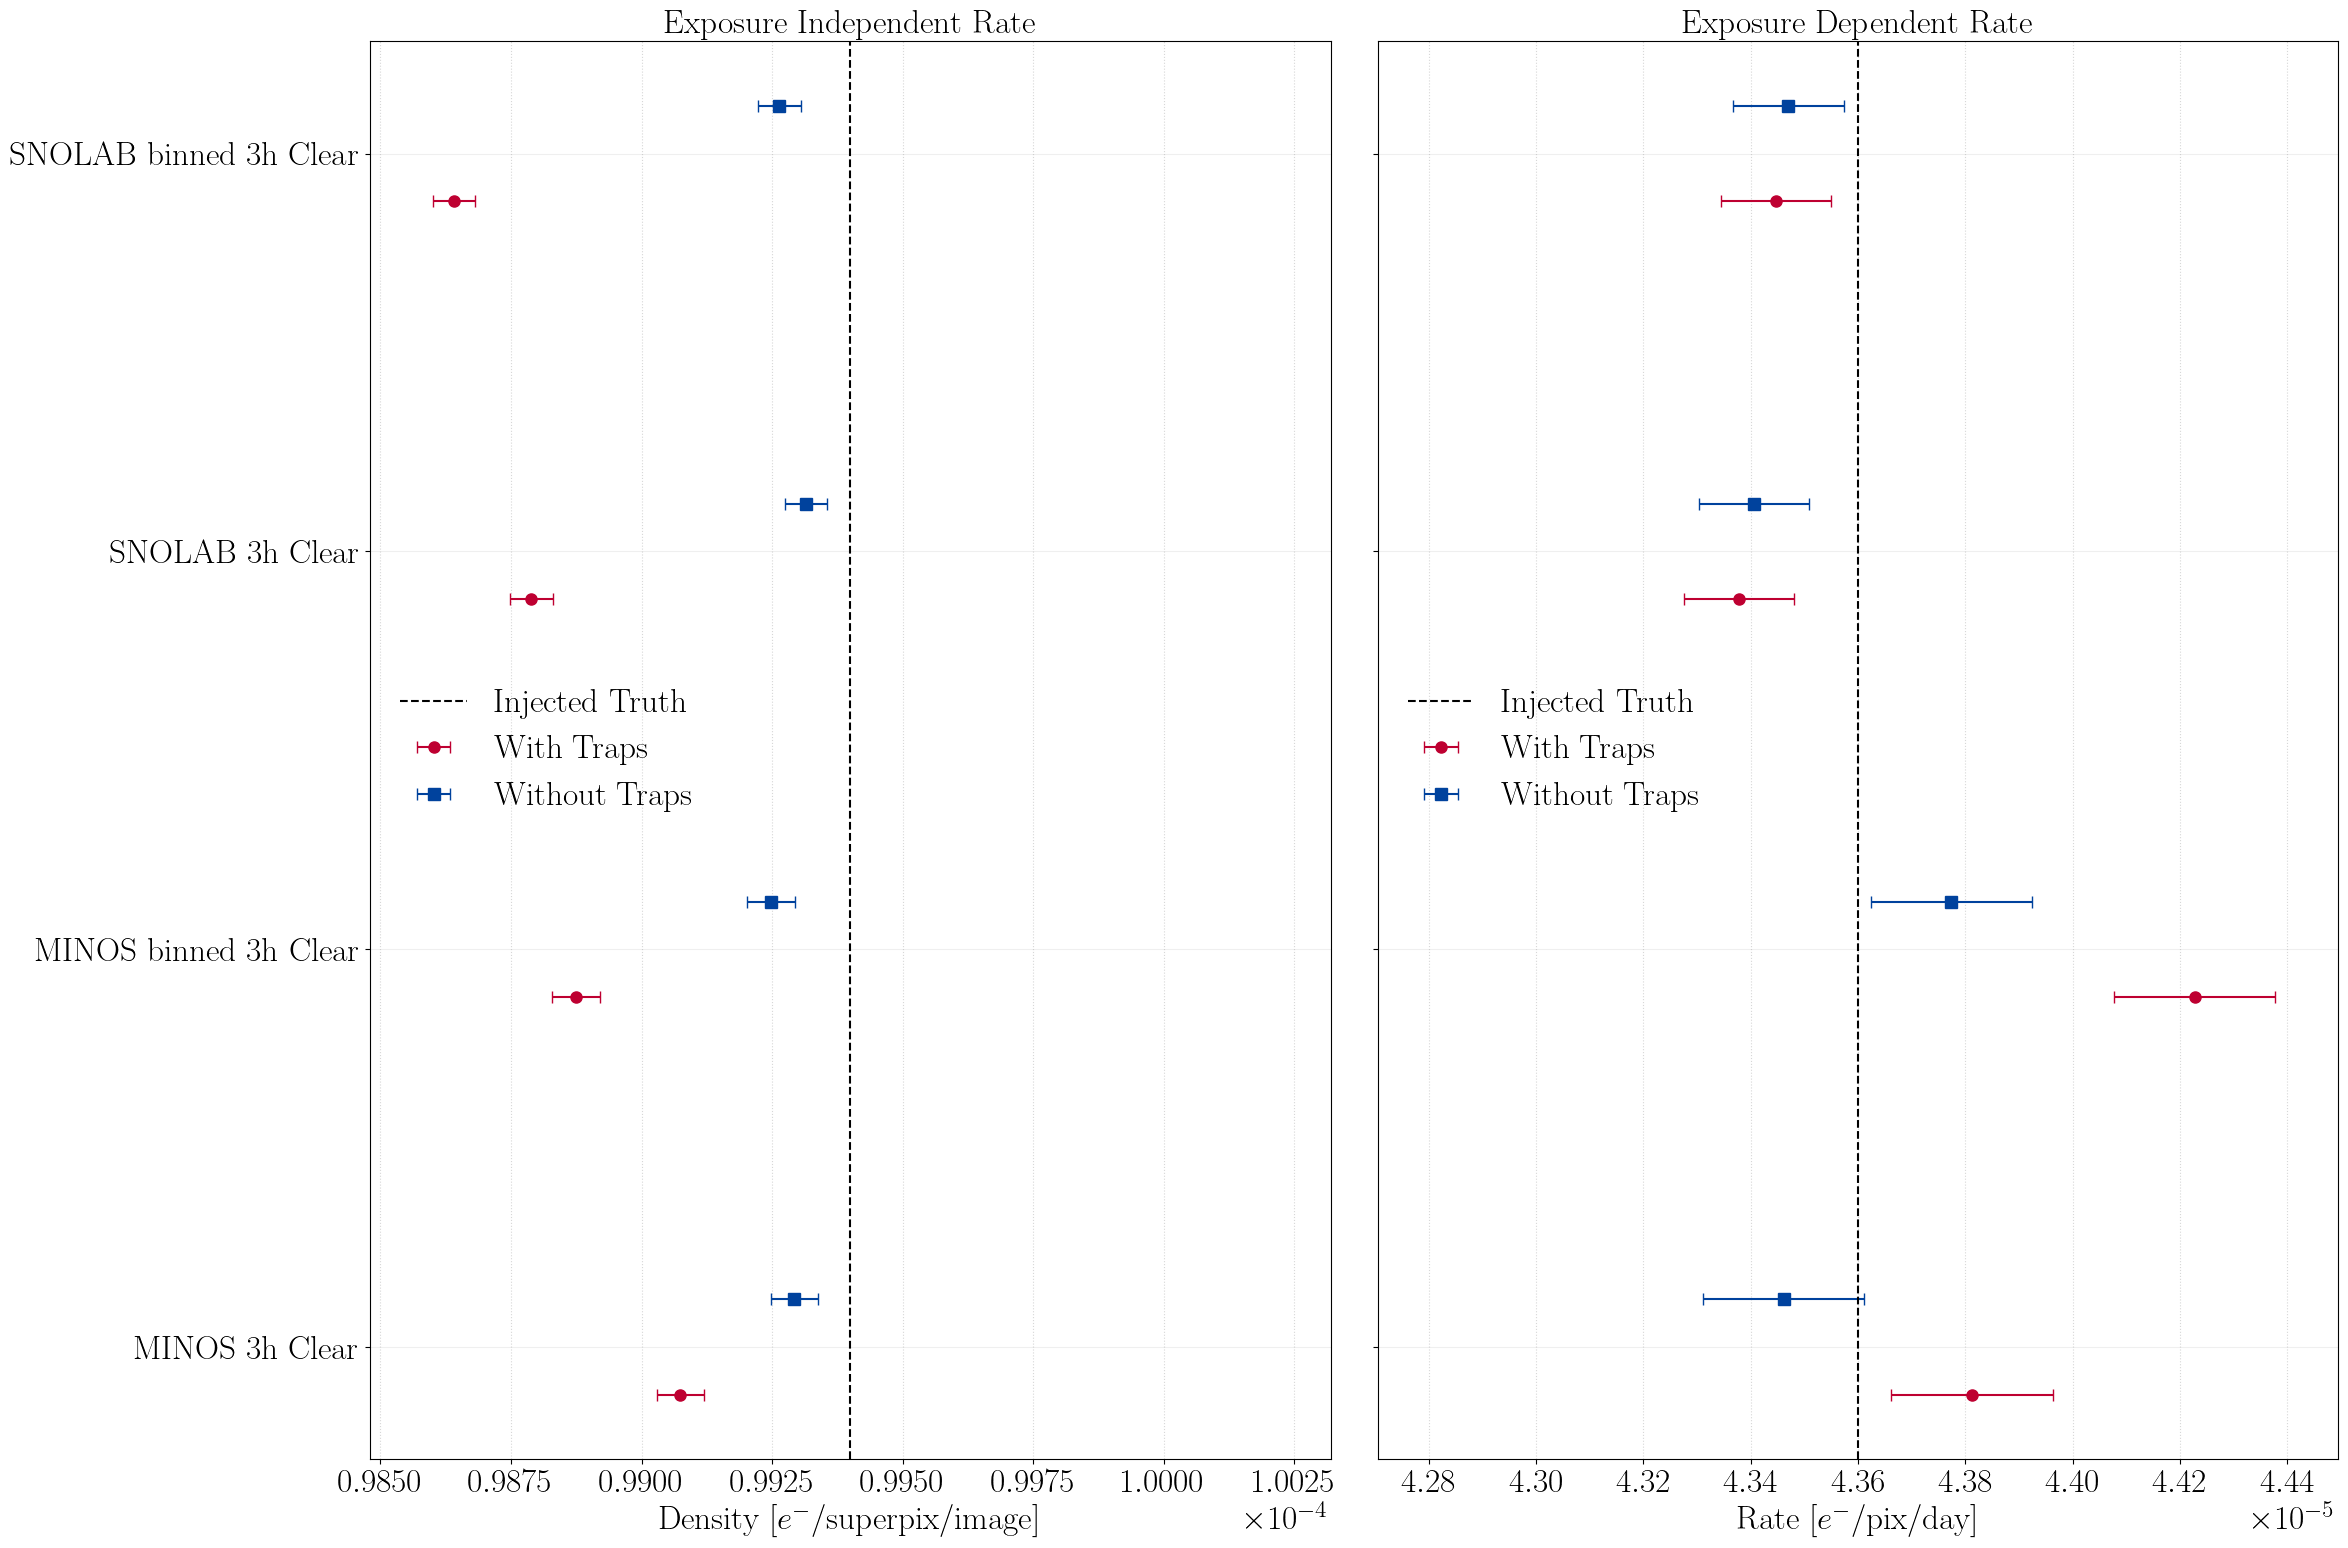

In [11]:
# res = compare_scenarios(scenarios, mask=MASK,event_type=event_type)
# res = compare_scenarios(scenarios_upper, mask=MASK,event_type=event_type)
res = compare_scenarios(scenarios_simple, mask=MASK,event_type=event_type,save_as='figures/simulation_comparison.pdf')

campaign\minos_effcorr_vp3_expind_pre_clear3h_shuf_zedr_minimal_caldet\aggregated_results_Halo+Bleed+HotColumn+HotPixel_1e.json
Cache not found. Processing raw HDF5 simulation files for 1e events...
Saving aggregated data to JSON cache...
campaign\minos_upper_vp3_expind_pre_clear3h_shuf_zedr_minimal_caldet\aggregated_results_Halo+Bleed+HotColumn+HotPixel_1e.json
Cache not found. Processing raw HDF5 simulation files for 1e events...
Saving aggregated data to JSON cache...
campaign\minos_effcorr_vp3_expind_pre_clear3h_shuf_bin32_zedr_minimal_caldet\aggregated_results_Halo+Bleed+HotColumn+HotPixel_1e.json
Cache not found. Processing raw HDF5 simulation files for 1e events...
Saving aggregated data to JSON cache...
campaign\minos_upper_vp3_expind_pre_clear3h_shuf_bin32_zedr_minimal_caldet\aggregated_results_Halo+Bleed+HotColumn+HotPixel_1e.json
Cache not found. Processing raw HDF5 simulation files for 1e events...
Saving aggregated data to JSON cache...
campaign\snolab_effcorr_vp3_expind_p

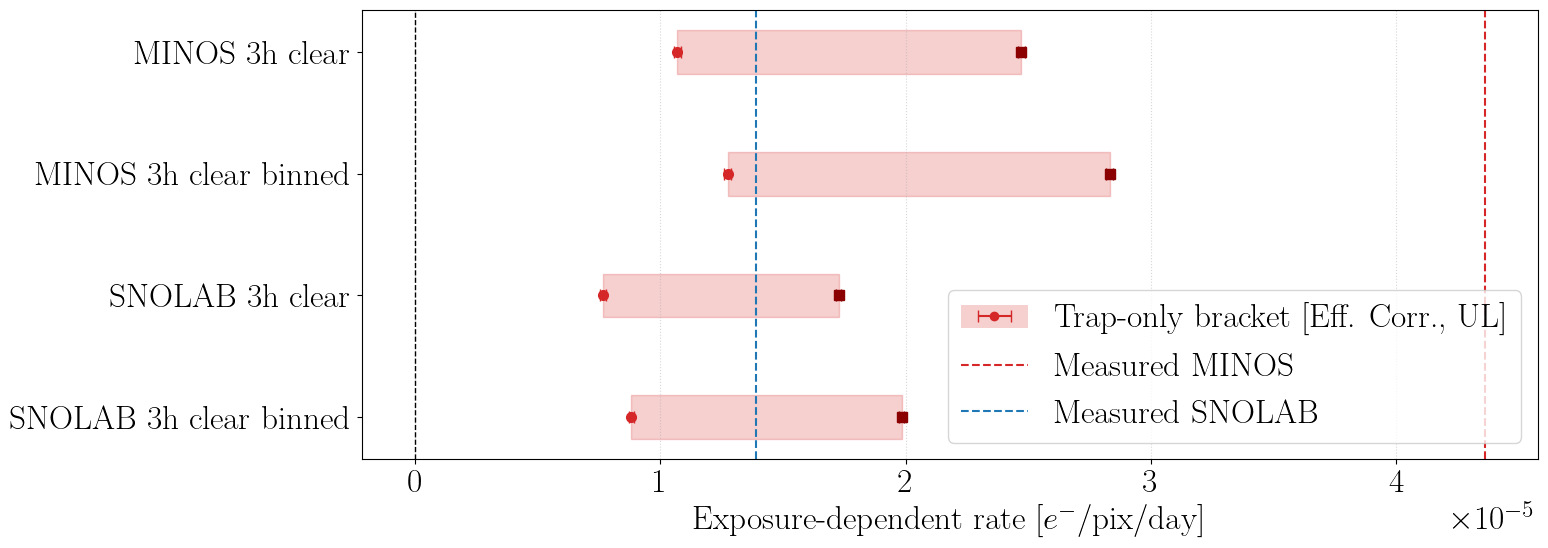

Efficiency Only Fraction of True Rate @ MINOS
1.0693013728958645e-05 24.525%
Upper Limit Fraction of True Rate @ MINOS
2.4719605380783404e-05 56.696%
MINOS 3h clear 
MINOS 3h clear               band=[1.069e-05, 2.472e-05]  truth=4.360e-05  floor=-1.90e-07  -> outside
Efficiency Only Fraction of True Rate @ MINOS
1.27528887000876e-05 29.25%
Upper Limit Fraction of True Rate @ MINOS
2.83139791995633e-05 64.94%
MINOS 3h clear binned 
MINOS 3h clear binned        band=[1.275e-05, 2.831e-05]  truth=4.360e-05  floor=-3.64e-09  -> outside
Efficiency Only Fraction of True Rate @ SNOLAB
7.657784556929436e-06 55.092%
Upper Limit Fraction of True Rate @ SNOLAB
1.7268662520215075e-05 124.235%
SNOLAB 3h clear 
SNOLAB 3h clear              band=[7.658e-06, 1.727e-05]  truth=4.360e-05  floor=1.33e-07  -> INSIDE (traps can explain)
Efficiency Only Fraction of True Rate @ SNOLAB
8.811216585866196e-06 63.39%
Upper Limit Fraction of True Rate @ SNOLAB
1.9829336857800276e-05 142.657%
SNOLAB 3h clear binn

In [12]:
from matplotlib.patches import Patch
from matplotlib.legend_handler import HandlerTuple
# === Trap-only bracket vs measured truth ===
# Zero dark-current campaign: with no injected exposure-dependent charge, the
# trap-branch exposure-dependent rate is BRACKETED by
#   effcorr -> MLE point estimate (empty tau bins -> 0; LOWER edge)
#   upper   -> 90% CL completeness fill (empty bins filled; UPPER edge)
# If the measured ("truth") exposure-dependent rate falls inside [effcorr, upper],
# charge traps alone can account for it.
#
# Reuses aggregate_scenario(spec) which resolves scenario_dir(population=...,
# zero_exp_dep=True) + plot_simulation_results (return idx 1 = trap-branch slope,
# 7 = its error, 3 = no-trap floor, 5 = injected/measured truth) and, when
# systematics=('vp',), folds the V_p {1,3,10} scan into an asymmetric band on the
# slope. Slopes are e/pix/hour; x24 -> e/pix/day.
#
# vp_band=True (default) marginalizes V_p: the effcorr/upper edges are the central
# (V_p=3) points and each carries a lighter outer cap = the V_p envelope, so the
# scan collapses into one row instead of separate vp=1/vp=10 rows. A per-config
# 'vp_band': False (optionally with an explicit 'vp') pins a single V_p and drops
# the band, for inspecting one V_p in isolation.

def trap_only_bracket(configs, exp_indep=exp_indep, flavor=sim_pipe,
                      base=CAMPAIGN_BASE, mask=MASK, event_type='1e', vp_band=False):
    """configs: list of (display_label, dict(cond=, clear=, order=, binning=,
    vp=, vp_band=)). By default V_p is folded into a systematic band; set
    'vp_band': False (and optionally 'vp') on a config to pin a single V_p."""
    SCALE = 24.0  # e/pix/hour -> e/pix/day (matches compare_scenarios)
    rows = []
    for disp, cfg in configs:
        spec = dict(condition=cfg['cond'], zero_exp_dep=True, flavor=flavor, base=base,
                    exp_indep=exp_indep, clear=cfg['clear'],
                    order=cfg.get('order', 'shuffled'), binning=cfg.get('binning', 1.0))
        if cfg.get('vp_band', vp_band):
            spec['systematics'] = ('vp',)            # marginalize V_p (ignore cfg vp)
        else:
            spec['vp'] = cfg.get('vp', 3.0)          # single V_p, no band
        eff_ct, eff_syst = aggregate_scenario({**spec, 'population': 'effcorr'},
                                              mask=mask, event_type=event_type)
        up_ct, up_syst = aggregate_scenario({**spec, 'population': 'upper'},
                                            mask=mask, event_type=event_type)
        if eff_ct is None or up_ct is None:
            print(f"skip {disp}: missing central results dir(s)")
            continue
        # V_p envelope on the exp-dependent slope (col 1); empty when no band.
        eff_band = tuple(v * SCALE for v in eff_syst[1]) if 1 in eff_syst else None
        up_band = tuple(v * SCALE for v in up_syst[1]) if 1 in up_syst else None
        rows.append(dict(label=disp,
                         lo=eff_ct[1] * SCALE, lo_err=eff_ct[7] * SCALE, lo_band=eff_band,
                         hi=up_ct[1] * SCALE, hi_err=up_ct[7] * SCALE, hi_band=up_band,
                         floor=eff_ct[3] * SCALE, truth=eff_ct[5] * SCALE))
    if not rows:
        print("No completed bracket scenarios found yet (run/sync the campaign first).")
        return rows

    y = np.arange(len(rows))
    truth = rows[0]['truth']
    truth_snolab = 1.39e-5
    fig, ax = plt.subplots(figsize=(16, max(4, 1.5 * len(rows))))
    band_labelled = False
    for i, r in enumerate(rows):
        lo, hi = sorted((r['lo'], r['hi']))
        ax.fill_betweenx([i - 0.18, i + 0.18], lo, hi, color='tab:red', alpha=0.22,)
                         #label='Trap-only band [Eff. Corr., UL]' if i == 0 else None)
        # V_p systematic: lighter outer cap on each population edge (drawn first).
        for val, bnd in ((r['lo'], r['lo_band']), (r['hi'], r['hi_band'])):
            if bnd is None:
                continue
            xerr = [[max(val - bnd[0], 0.0)], [max(bnd[1] - val, 0.0)]]
            ax.errorbar(val, i, xerr=xerr, fmt='none', ecolor='dimgray', alpha=0.6,
                        elinewidth=5, capsize=0,)
                        #label=r'$V_p$ systematic' if not band_labelled else None)
            band_labelled = True
        ax.errorbar(r['lo'], i, xerr=r['lo_err'], fmt='o', color='tab:red', capsize=4,
                    markersize=7,) 
                    #label='effcorr (lower edge)' if i == 0 else None)
        ax.errorbar(r['hi'], i, xerr=r['hi_err'], fmt='s', color='darkred', capsize=4,
                    markersize=7,) 
                  #  label='upper (upper edge)' if i == 0 else None)
        #ax.plot(r['floor'], i, 'x', color='tab:blue', markersize=9,
                #label='no-trap floor (~0)' if i == 0 else None)
    ax.axvline(truth, color='tab:red', ls='--', lw=1.5, label='Measured MINOS')
    ax.axvline(truth_snolab, color='tab:blue', ls='--', lw=1.5, label='Measured SNOLAB')
    ax.axvline(0, color='black', ls='--', lw=1)

    ax.set_yticks(y)
    ax.set_yticklabels([r['label'] for r in rows])
    ax.invert_yaxis()
    ax.set_xlabel(r'Exposure-dependent rate [$e^-$/pix/day]')
    # ax.set_title('Trap-only bracket vs measured exposure-dependent rate')
    ax.grid(True, axis='x', ls=':', alpha=0.5)
    ax.ticklabel_format(style='sci', axis='x', scilimits=(0, 0))
    # Composite legend handle: uncertainty band + error bar
    band_proxy = Patch(
        facecolor='tab:red',
        edgecolor='none',
        alpha=0.22,
    )

    errorbar_proxy = ax.errorbar(
        np.nan, np.nan,
        xerr=1.0,
        fmt='o',
        color='tab:red',
        capsize=4,
        markersize=6,
    )

    trap_handle = (band_proxy, errorbar_proxy)
    handles, labels = ax.get_legend_handles_labels()

    handles = [trap_handle] + handles
    labels = ['Trap-only bracket [Eff. Corr., UL]'] + labels

    ax.legend(
        handles,
        labels,
        handler_map={
            tuple: HandlerTuple(ndivide=1, pad=0),
        },
        frameon=True,
        loc='best',
    )
    # ax.legend(
    #     handles,
    #     labels,
    #     handler_map={
    #         tuple: HandlerTuple(ndivide=1, pad=0),
    #     },
    #     frameon=False,
    #     loc='center left',
    #     bbox_to_anchor=(1.02, 0.5),
    # )


    plt.tight_layout()
    out = Path(figures_dir()) / "trap_bracket.pdf"
    plt.savefig(out,dpi=300)
    plt.show()
    plt.close()

    for r in rows:
        frac_denom =  r['truth'] if 'MINOS' in r['label'] else truth_snolab
        experiment_str = 'MINOS' if 'MINOS' in r['label'] else "SNOLAB"
        lo, hi = sorted((r['lo'], r['hi']))
        inside = lo <= frac_denom <= hi
        print(f"Efficiency Only Fraction of True Rate @ {experiment_str}")
        print(lo, f"{np.round(100*(lo / frac_denom),3)}%")
        print(f"Upper Limit Fraction of True Rate @ {experiment_str}")

        print(hi, f"{np.round(100*(hi / frac_denom),3)}%")
        verdict = 'INSIDE (traps can explain)' if inside else 'outside'
        print(r['label'],"" )
        print(f"{r['label']:<28} band=[{lo:.3e}, {hi:.3e}]  truth={r['truth']:.3e}  "
              f"floor={r['floor']:.2e}  -> {verdict}")
    return rows


# Default: both conditions x both clears, V_p folded into a systematic band.
# Add binning=32 for the binned variants; set 'vp_band': False (+ 'vp') on a
# config to pin one V_p, or order='ordered' to inspect the biased legacy cycle.
bracket_configs = [
    ('MINOS 3h clear',          dict(cond='minos',  clear='three_hour')),
    ('MINOS 3h clear binned',   dict(cond='minos',  clear='three_hour', binning=32)),
    # ('MINOS clear seq',         dict(cond='minos',  clear='sequencer')),
    ('SNOLAB 3h clear',         dict(cond='snolab', clear='three_hour')),
    ('SNOLAB 3h clear binned',  dict(cond='snolab', clear='three_hour', binning=32)),
    # ('SNOLAB clear seq',        dict(cond='snolab', clear='sequencer')),
]
bracket_rows = trap_only_bracket(bracket_configs)


In [ ]:
bracket_rows[0]['truth']

In [ ]:
T = 135 #K
sigma = 1e-15 #representative value
M_COND_HOLE = 0.41
M_DENS_HOLE = 0.94
t1 = 0

t2 = 50 *1e-3 #50ms
kb = 8.617333262e-5 #eV/K
h = 4.135667696e-15 #eV s
me = 0.510998950e6 #eV
ccms = 2.99792458e10 #cm/s
# denom = 2 * np.sqrt(3) * (2 * np.pi)**(3/2) * (M_DENS_HOLE * me)**(3/2) / np.sqrt(M_COND_HOLE * me)
# kbT = kb * temperatures
# scaling_factor =  (h**3) * (ccms**2) / denom
v_th = hole_thermal_velocity(T)
def hole_thermal_velocity(T):
    """v_th = sqrt(3 k_B T / m_cond) for holes, in cm/s."""
    return ccms * np.sqrt(3 * kb * T / (M_COND_HOLE * me))


tau_c = 1/(sigma*v_th*n)
pc = np.exp(-1* t1 / tau_c) - np.exp(-1* t2 / tau_c)

pc


## 6. Archive (scratch — review later)
Cells below were commented-out, duplicated, or purely exploratory in the original
notebook. They are preserved verbatim and are **not** part of the figure pipeline.

In [ ]:
<recipe name="vpump">
<step state="STATE_11"	delay="delay_Tph"/>
<step state="STATE_12"	delay="delay_Tphshort"/>
<step state="STATE_13"	delay="delay_Tph_long"/>
<step state="STATE_12"	delay="delay_Tphshort"/>
<step state="STATE_11"	delay="delay_Tph"/>
    <step state="STATE_16A"  delay="delay_Tphshort"/>	
    <step state="STATE_15"  delay="delay_Tph_long"/>
    <step state="STATE_16A"  delay="delay_Tphshort"/>
</recipe>

In [ ]:
<state name="STATE_11"   val="V1A | V1B |       V3A | V3B | H1A | H1B |       H3A | H3B |             RGA | RGB | OGA | OGB | DGA | DGB                        "/>
<state name="STATE_12"   val="V1A | V1B |                   H1A | H1B |       H3A | H3B |             RGA | RGB | OGA | OGB | DGA | DGB                        "/>
<state name="STATE_13"   val="V1A | V1B | V2C |             H1A | H1B |       H3A | H3B |             RGA | RGB | OGA | OGB | DGA | DGB                        "/>
<state name="STATE_12"   val="V1A | V1B |                   H1A | H1B |       H3A | H3B |             RGA | RGB | OGA | OGB | DGA | DGB                        "/>
<state name="STATE_11"   val="V1A | V1B |       V3A | V3B | H1A | H1B |       H3A | H3B |             RGA | RGB | OGA | OGB | DGA | DGB                        "/>

    <state name="STATE_16A"  val="                  V3A | V3B | H1A | H1B |	  H3A | H3B |             RGA | RGB | OGA | OGB | DGA | DGB                        "/>

    <state name="STATE_15"   val="            V2C | V3A | V3B | H1A | H1B |       H3A | H3B |             RGA | RGB | OGA | OGB | DGA | DGB                        "/>

    <state name="STATE_16A"  val="                  V3A | V3B | H1A | H1B |	  H3A | H3B |             RGA | RGB | OGA | OGB | DGA | DGB                        "/>




In [ ]:
# from pympler import asizeof

In [ ]:
# print(asizeof.asizeof(dipole_spectra)*1e-9
#       ) # Returns total recursive size

# print(asizeof.asizeof(fit_dipole_spectra)*1e-9
#       ) # Returns total recursive size

In [ ]:
# np.linspace(0,1,6)

In [ ]:
# cross_sections = np.array(energy_crossSections)[:,0]
# energies = np.array(energy_crossSections)[:,1]
# plt.figure(figsize=(8,6))

# plt.hist(energies,bins=np.linspace(0,0.8,50))
# # plt.yscale('log')
# plt.xticks(np.linspace(0,0.8,5))
# plt.xlabel("Fitted Trap Energy $E$ [eV]")

# plt.ylabel("Counts")

# plt.show()
# plt.close()

# plt.figure(figsize=(8,6))
# plt.hist(cross_sections,bins=np.geomspace(1e-25,1e-10,50))
# plt.xscale('log')
# plt.xticks(np.geomspace(1e-25,1e-10,6))
# plt.xlabel("Fitted Capture Cross-Section $\sigma$ [cm$^2$]")
# plt.ylabel("Counts")
# plt.show()
# plt.close()

In [ ]:
# import matplotlib as mpl
# fig, ax = plt.subplots(figsize=(8,6))

# h = ax.hist2d(
#     cross_sections, energies,
#     bins=[np.geomspace(1e-25, 1e-10, 40), np.linspace(0, 0.7, 40)],
#     cmap='viridis',
#     norm=mpl.colors.LogNorm()

# )

# ax.set_xscale('log')
# ax.set_xlabel(r"Fitted Capture Cross-Section $\sigma$ [cm$^2$]")

# ax.set_ylabel(r"Fitted Trap Energy $E$ [eV]")

# fig.colorbar(h[3], ax=ax, label='Counts')

# plt.tight_layout()
# plt.show()
# plt.close()

In [ ]:
# def parse_bool(value):
#     return str(value).strip().lower() in {"true", "1", "yes"}


# tau_135_records = []
# E_records = []
# measured_135 = []
# with records4_path.open(newline="") as handle:
#     for row in csv.DictReader(handle):
#         tau_135_records.append(float(row["tau_135_seconds"]))
#         E_records.append(float(row["E_eV"]))
#         measured_135.append(parse_bool(row["tau_135_good_intensity_fit"]))

# tau_135_records = np.asarray(tau_135_records, dtype=float)
# E_records = np.asarray(E_records, dtype=float)
# measured_135 = np.asarray(measured_135, dtype=bool)
# extrapolated_135 = ~measured_135

# print(f"Direct good 135 K tau fits: {int(measured_135.sum())}")
# print(f"Extrapolated-only tau_135 values: {int(extrapolated_135.sum())}")
# print("Median tau_135 direct 135 K:", np.median(tau_135_records[measured_135]))
# print("Median tau_135 extrapolated-only:", np.median(tau_135_records[extrapolated_135]))

# fig, (ax_scatter, ax_hist) = plt.subplots(
#     2,
#     1,
#     figsize=(16*0.8, 2*9*0.8),
#     sharex=True,
#     gridspec_kw={"height_ratios": [1.0, 1.0]},
# )

# ax_scatter.scatter(
#     tau_135_records[extrapolated_135],
#     E_records[extrapolated_135],
#     s=12,
#     alpha=0.35,
#     color="tab:blue",
#     label="Extrapolated",
# )
# ax_scatter.scatter(
#     tau_135_records[measured_135],
#     E_records[measured_135],
#     s=16,
#     alpha=0.55,
#     color="tab:green",
#     label="Measured",
# )
# ax_scatter.set_xscale("log")
# ax_scatter.set_ylabel("$E$ [eV]")
# # ax_scatter.set_title("Direct 135 K measurements and extrapolated tau_135 in energy space")
# ax_scatter.legend(fontsize=small, loc="best")
# ax_scatter.grid(True, which="both", alpha=0.15)

# hist_bins = tau_edges
# ax_hist.hist(
#     [tau_135_records[extrapolated_135], tau_135_records[measured_135]],
#     bins=hist_bins,
#     stacked=True,
#     color=["tab:blue", "tab:green"],
#     alpha=0.65,
#     label=["Extrapolated", "Measured"],
# )
# ax_hist.set_xscale("log")
# ax_hist.set_yscale("log")
# ax_hist.set_xlabel("$\\tau_e(135\,\mathrm{K})$ [s]")
# ax_hist.set_ylabel("\# of Traps")
# ax_hist.grid(True, which="both", alpha=0.15)
# ax_hist.axvline(3600,label='1 hour',ls='--',color=C_REF)
# ax_hist.axvline(3600*24,label='1 day',ls='--',color=C_REF)
# ax_hist.axvline(3600*25*365.25,label='1 year',ls='--',color=C_REF)
# ax_hist.legend(fontsize=small, loc="best")

# plt.tight_layout()
# plt.show()


In [ ]:
# len(avg_A),len(avg_B),len(avg_C)

In [ ]:
# import hist
# from hist import Hist
# # fig,ax = plt.subplots(1,2,figsize=(14,6))

# # for t in tau_temperatures.keys():
# t = 135
# fig = plt.figure(figsize=(9,6))
# ax = plt.gca()
# measured_taus = tau_temperatures[t]['measured']
# extrapolated_taus = tau_temperatures[t]['extrapolated']

# print(len(measured_taus))
# print(len(extrapolated_taus))
# minbin = np.min([np.min(measured_taus),np.min(extrapolated_taus)])
# maxbin = np.max([np.max(measured_taus),np.max(extrapolated_taus)])

# bins = np.geomspace(1e-5,1e8,35)

# # mhist= Hist.new.Log(200, minbin, maxbin, name="Measured Emission Times").Weight()
# # ehist= Hist.new.Log(200, minbin, maxbin, name="Extrapolated Emission Times").Weight()

# # mhist.fill(measured_taus)
# # ehist.fill(extrapolated_taus)

# # mhist,mbins = np.histogram(measured_taus,bins=bins)
# # ehist,ebins = np.histogram(extrapolated_taus,bins=bins)

# # plt.stairs(mhist,mbins,color='blue',label='measured',lw=2)
# # plt.stairs(ehist,ebins,color='grey',label='extrapolated',lw=2)
# # mhist.plot1d(ax=ax[0],histtype='fill',yerr=False)
# # ehist.plot1d(ax=ax[1],histtype='fill',yerr=False)


# # ax.hist(measured_taus+extrapolated_taus, bins, color=C_REF, edgecolor='black', alpha=1,label='Total')
# ax.hist(extrapolated_taus, bins, color=C_BLUE, edgecolor='black', alpha=0.8,label='Extrapolated')
# ax.hist(measured_taus, bins, color='seagreen', edgecolor='black', alpha=0.8,label='Measured')


# # ax.legend(fontsize=16)
# # ax.set_title(f"Emission $\\tau_e$ of CCD Traps at {t}k",fontsize=20)
# # ax[1].set_title("Extrapolated Emission $\\tau_e$ of CCD Traps at 135k",fontsize=20)
# # for a in ax:
# ax.set_xlabel('$\\tau_e$ [s]',fontsize=small)
# ax.set_ylabel("\# of Traps",fontsize=small)
# ax.set_xscale('log')
# ax.set_yscale('log')
# # ax.set_ylim(0,500)
# # ax[0].set_ylim(0,50)
# plt.axvline(3600,label='1h',ls='--',color=C_REF)
# plt.axvline(3600*24,label='1 day',ls='-.',color=C_REF)
# plt.axvline(3600*24*365,label='1 year',ls=':',color=C_REF)
# ax.legend(frameon=False,loc='upper left')
# ax.minorticks_on()
# plt.savefig(f'figures/tau_at_{t}k_hist.pdf',dpi=300)
# plt.show()
# plt.close()

In [ ]:


# # 1. Aggregate data across all temperatures
# all_measured_taus = []
# all_extrapolated_taus = []

# for t in tau_temperatures.keys():
#     all_measured_taus.extend(tau_temperatures[t]['measured'])
#     all_extrapolated_taus.extend(tau_temperatures[t]['extrapolated'])

# all_total_taus = all_measured_taus + all_extrapolated_taus

# print(f"Total Traps Measured: {len(all_measured_taus)}")
# print(f"Total Traps Extrapolated: {len(all_extrapolated_taus)}")

# if len(all_total_taus) > 0:
#     # 2. Set up the Two-Panel Plot
#     fig, axes = plt.subplots(2, 1, figsize=(12, 10), gridspec_kw={'height_ratios': [1, 1]}, sharex=True)
#     ax_hist = axes[0]
#     ax_eff = axes[1]
    
#     # bins = np.geomspace(1e-7, 1e8, 75)

#     # --- Top Panel: Stacked Histogram ---
#     ax_hist.hist([all_measured_taus, all_extrapolated_taus], bins=bins, stacked=True, 
#                  color=['seagreen', C_BLUE], edgecolor='black', alpha=0.8, 
#                  label=['Measured', 'Extrapolated (Missed)'])

#     # ax_hist.set_title("Net Emission $\\tau_e$ of CCD Traps (All Temperatures Integrated)", fontsize=20)
#     ax_hist.set_ylabel("\\# of Traps (All Temperatures)", fontsize=medium)
#     # ax_hist.set_yscale('log')
    
#     # ax_hist.axvline(3600, label='1h', ls='--', color=C_REF)
#     # ax_hist.axvline(3600*24, label='1 day', ls='-.', color=C_REF)
#     # ax_hist.axvline(3600*24*365, label='1 year', ls=':', color=C_REF)
#     ax_hist.legend(frameon=False, fontsize=medium)

#     # --- Bottom Panel: Net Efficiency ---
#     meas_counts, _ = np.histogram(all_measured_taus, bins=bins)
#     tot_counts, _ = np.histogram(all_total_taus, bins=bins)
    
#     # Safely calculate efficiency
#     with np.errstate(divide='ignore', invalid='ignore'):
#         efficiency = meas_counts / tot_counts
        
#     bin_centers = np.sqrt(bins[:-1] * bins[1:])
    
#     # Calculate binomial errors
#     eff_err = np.zeros_like(efficiency)
#     valid = tot_counts > 0
#     eff_err[valid] = np.sqrt(efficiency[valid] * (1.0 - efficiency[valid]) / tot_counts[valid])
    
#     ax_eff.errorbar(bin_centers[valid], efficiency[valid], yerr=eff_err[valid], 
#                     fmt='o', color='black', markersize=5, capsize=3)
    
#     # Formatting
#     ax_eff.set_xlabel('$\\tau_e$ [s]', fontsize=medium)
#     ax_eff.set_ylabel("Net Efficiency $\\epsilon$", fontsize=medium)
#     ax_eff.set_xscale('log')
#     ax_eff.set_ylim(-0.1, 1.1)
#     ax_eff.axhline(1.0, color='grey', ls=':', alpha=0.5)
#     ax_eff.axhline(0.0, color='grey', ls=':', alpha=0.5)
#     ax_eff.grid(True, which='both', axis='x', alpha=0.2)

#     plt.tight_layout()
    
#     plt.show()
#     plt.close()
# else:
#     print("No data available to plot.")


In [ ]:


# # 1. Aggregate data across all temperatures
# all_measured_taus = []
# all_extrapolated_taus = []

# for t in tau_temperatures.keys():
#     all_measured_taus.extend(tau_temperatures[t]['measured'])
#     all_extrapolated_taus.extend(tau_temperatures[t]['extrapolated'])

# all_total_taus = all_measured_taus + all_extrapolated_taus

# print(f"Total Traps Measured: {len(all_measured_taus)}")
# print(f"Total Traps Extrapolated: {len(all_extrapolated_taus)}")

# if len(all_total_taus) > 0:
#     # 2. Set up the Two-Panel Plot
#     # fig, axes = plt.subplots(2, 1, figsize=(12, 10), gridspec_kw={'height_ratios': [1, 1]}, sharex=True)
#     fig = plt.figure(figsize=(12,6))
#     ax_hist = plt.gca()
#     # ax_eff = axes[1]
    
#     # bins = np.geomspace(1e-7, 1e8, 50)

#     # --- Top Panel: Stacked Histogram ---
#     ax_hist.hist([all_measured_taus, all_extrapolated_taus], bins=bins, stacked=True, 
#                  color=['seagreen', C_BLUE], edgecolor='black', alpha=0.8, 
#                  label=['Measured', 'Extrapolated (Missed)'])

#     # ax_hist.set_title("Net Emission $\\tau_e$ of CCD Traps (All Temperatures Integrated)", fontsize=20)
#     ax_hist.set_ylabel("\\# of Traps (All Temperatures)", fontsize=medium)
#     ax_hist.set_xscale('log')
    
#     # ax_hist.axvline(3600, label='1h', ls='--', color=C_REF)
#     # ax_hist.axvline(3600*24, label='1 day', ls='-.', color=C_REF)
#     # ax_hist.axvline(3600*24*365, label='1 year', ls=':', color=C_REF)
#     ax_hist.legend(frameon=False, fontsize=medium)

#     # --- Bottom Panel: Net Efficiency ---
#     # meas_counts, _ = np.histogram(all_measured_taus, bins=bins)
#     # tot_counts, _ = np.histogram(all_total_taus, bins=bins)
    
#     # Safely calculate efficiency
#     # with np.errstate(divide='ignore', invalid='ignore'):
#         # efficiency = meas_counts / tot_counts
        
#     bin_centers = np.sqrt(bins[:-1] * bins[1:])
    
#     # # Calculate binomial errors
#     # eff_err = np.zeros_like(efficiency)
#     # valid = tot_counts > 0
#     # eff_err[valid] = np.sqrt(efficiency[valid] * (1.0 - efficiency[valid]) / tot_counts[valid])
    
#     # ax_eff.errorbar(bin_centers[valid], efficiency[valid], yerr=eff_err[valid], 
#     #                 fmt='o', color='black', markersize=5, capsize=3)
    
#     # # Formatting
#     ax_hist.set_xlabel('$\\tau_e$ [s]', fontsize=medium)
#     # ax_eff.set_ylabel("Net Efficiency $\\epsilon$", fontsize=medium)
#     # ax_eff.set_xscale('log')
#     # ax_eff.set_ylim(-0.1, 1.1)
#     # ax_eff.axhline(1.0, color='grey', ls=':', alpha=0.5)
#     # ax_eff.axhline(0.0, color='grey', ls=':', alpha=0.5)
#     # ax_eff.grid(True, which='both', axis='x', alpha=0.2)

#     plt.tight_layout()
    
#     plt.show()
#     plt.close()
# else:
#     print("No data available to plot.")


In [ ]:

# # 1. Aggregate data across all temperatures
# all_measured_taus = []
# all_extrapolated_taus = []

# for t in tau_temperatures.keys():
#     all_measured_taus.extend(tau_temperatures[t]['measured'])
#     all_extrapolated_taus.extend(tau_temperatures[t]['extrapolated'])

# all_total_taus = all_measured_taus + all_extrapolated_taus

# print(f"Total Traps Measured: {len(all_measured_taus)}")
# print(f"Total Traps Extrapolated: {len(all_extrapolated_taus)}")

# if len(all_total_taus) > 0:
#     # 2. Set up the Two-Panel Plot
#     # fig, axes = plt.subplots(2, 1, figsize=(12, 10), gridspec_kw={'height_ratios': [1, 1]}, sharex=True)
#     fig = plt.figure(figsize=(12,6))
#     # ax_hist = plt.gca()
#     ax_eff =  plt.gca()
    
#     # bins = np.geomspace(1e-7, 1e8, 75)

#     # --- Top Panel: Stacked Histogram ---
#     # ax_hist.hist([all_measured_taus, all_extrapolated_taus], bins=bins, stacked=True, 
#                 #  color=['seagreen', C_BLUE], edgecolor='black', alpha=0.8, 
#                 #  label=['Measured', 'Extrapolated (Missed)'])

#     # ax_hist.set_title("Net Emission $\\tau_e$ of CCD Traps (All Temperatures Integrated)", fontsize=20)
#     # ax_hist.set_ylabel("\\# of Traps (All Temperatures)", fontsize=medium)
#     ax_eff.set_xscale('log')
    
#     # ax_hist.axvline(3600, label='1h', ls='--', color=C_REF)
    
#     # ax_hist.axvline(3600*24, label='1 day', ls='-.', color=C_REF)
#     # ax_hist.axvline(3600*24*365, label='1 year', ls=':', color=C_REF)
#     # ax_hist.legend(frameon=False, fontsize=medium)

#     # --- Bottom Panel: Net Efficiency ---
#     meas_counts, _ = np.histogram(all_measured_taus, bins=bins)
#     tot_counts, _ = np.histogram(all_total_taus, bins=bins)
    
#     # Safely calculate efficiency
#     with np.errstate(divide='ignore', invalid='ignore'):
#         efficiency = meas_counts / tot_counts
        
#     bin_centers = np.sqrt(bins[:-1] * bins[1:])
    
#     # Calculate binomial errors
#     eff_err = np.zeros_like(efficiency)
#     valid = tot_counts > 0
#     eff_err[valid] = np.sqrt(efficiency[valid] * (1.0 - efficiency[valid]) / tot_counts[valid])
    
#     ax_eff.errorbar(bin_centers[valid], efficiency[valid], yerr=eff_err[valid], 
#                     fmt='o', color='black', markersize=3, capsize=3)
    
#     # # Formatting
#     ax_eff.set_xlabel('$\\tau_e$ [s]', fontsize=small)
#     ax_eff.set_ylabel("Efficiency of Measurement", fontsize=small)
#     ax_eff.set_xscale('log')
#     ax_eff.set_ylim(-0.1, 1.1)
#     ax_eff.minorticks_on()
#     # ax_eff.axhline(1.0, color='grey', ls=':', alpha=0.5)
#     # ax_eff.axhline(0.0, color='grey', ls=':', alpha=0.5)
#     # ax_eff.grid(True, which='both', axis='x', alpha=0.2)

#     plt.tight_layout()
#     plt.savefig('figures/efficiency_tau_curve.pdf',dpi=300)
#     plt.show()
#     plt.close()
# else:
#     print("No data available to plot.")


In [ ]:

# # ====================================================================
# # 1. Build the Universal "Master Efficiency Curve"
# # ====================================================================
# all_measured = []
# all_extrapolated = []
# for t in tau_temperatures.keys():
#     all_measured.extend(tau_temperatures[t]['measured'])
#     all_extrapolated.extend(tau_temperatures[t]['extrapolated'])

# all_total = all_measured + all_extrapolated
# # bins = np.geomspace(1e-7, 1e8, 75)

# meas_counts, _ = np.histogram(all_measured, bins=bins)
# tot_counts, _ = np.histogram(all_total, bins=bins)

# # Calculate efficiency safely
# with np.errstate(divide='ignore', invalid='ignore'):
#     master_efficiency = meas_counts / tot_counts
    
# bin_centers = np.sqrt(bins[:-1] * bins[1:])

# # Create a safe trust window (only trust regions with > 5% efficiency)
# trust_mask = (master_efficiency > 0.05) & (~np.isnan(master_efficiency))

# # Create a continuous interpolation function for the efficiency
# # master_eff_func = interp1d(
# #     bin_centers[trust_mask], 
# #     master_efficiency[trust_mask], 
# #     kind='linear', 
# #     bounds_error=False, 
# #     fill_value=np.nan
# # )

# master_eff_func = interp1d(
#     bin_centers, 
#     master_efficiency, 
#     kind='linear', 
#     bounds_error=False, 
#     fill_value=np.nan
# )

# # ====================================================================
# # 2. Weight every characterized trap based on where it was observed
# # ====================================================================
# target_temp = 135.0

# tau_target_list = []
# weights_list = []

# for d, data in enumerate(energy_crossSections):
#     cs = data[0]
#     energy = data[1]
#     avgtemp = data[4]  # The temperature where this trap was best measured
    
#     # Calculate the tau of this trap AT THE TEMPERATURE IT WAS MEASURED
#     logtau_obs = log_energy_cross_section(avgtemp, energy, np.log(cs))
#     tau_obs = np.exp(logtau_obs)
    
#     # Get the efficiency for this tau from our master curve
#     trap_eff = master_eff_func(tau_obs)
    
#     # Skip traps that fell outside our 5% reliable interpolation window
#     if np.isnan(trap_eff) or trap_eff <= 0:
#         continue 
        
#     trap_weight = 1.0 / trap_eff
    
#     # Now, calculate the tau of this trap at our TARGET extrapolated temperature
#     logtau_target = log_energy_cross_section(target_temp, energy, np.log(cs))
#     tau_target = np.exp(logtau_target)
    
#     tau_target_list.append(tau_target)
#     weights_list.append(trap_weight)

# # ====================================================================
# # 3. Plot the final Corrected Histogram!
# # ====================================================================
# plt.figure(figsize=(10, 6))

# # Plot the Unweighted (Raw Known Traps)
# plt.hist(tau_target_list, bins=bins, color=C_BLUE, edgecolor='black', 
#          alpha=0.6, label='Raw Known Traps (Uncorrected)')

# # Plot the Weighted (True Extrapolated Estimate)
# plt.hist(tau_target_list, bins=bins, weights=weights_list, 
#          edgecolor=C_RED, lw=2, histtype='step', 
#          label='Efficiency-Corrected (True Estimate)')

# plt.title(f"Emission $\\tau_e$ at {int(target_temp)}K (Corrected for Missed Traps)", fontsize=16)
# plt.xlabel('$\\tau_e$ [s]', fontsize=14)
# plt.ylabel('Estimated \# of Traps', fontsize=14)
# plt.xscale('log')
# plt.yscale('log')

# plt.axvline(3600, label='1h', ls='--', color=C_REF)
# plt.axvline(3600*24, label='1 day', ls='-.', color=C_REF)
# plt.axvline(3600*24*365, label='1 year', ls=':', color=C_REF)

# plt.legend(frameon=False, fontsize=12)
# plt.grid(True, alpha=0.3)
# plt.show()


In [ ]:
# # Improved pooled efficiency estimate and correction helpers
# from scipy.stats import beta

# def jeffreys_binomial_interval(k, n, confidence_level=0.68):
#     k = np.asarray(k, dtype=float)
#     n = np.asarray(n, dtype=float)
#     alpha = 1.0 - confidence_level
#     lo = np.full_like(k, np.nan, dtype=float)
#     hi = np.full_like(k, np.nan, dtype=float)
#     valid = n > 0
#     lo[valid] = beta.ppf(alpha / 2.0, k[valid] + 0.5, n[valid] - k[valid] + 0.5)
#     hi[valid] = beta.ppf(1.0 - alpha / 2.0, k[valid] + 0.5, n[valid] - k[valid] + 0.5)
#     return lo, hi

# def poisson_binomial_at_least(probabilities, k_min):
#     probabilities = np.asarray(probabilities, dtype=float)
#     probabilities = probabilities[np.isfinite(probabilities)]
#     if len(probabilities) < k_min:
#         return 0.0
#     pmf = np.array([1.0])
#     for p in probabilities:
#         p = np.clip(p, 0.0, 1.0)
#         updated = np.zeros(len(pmf) + 1)
#         updated[:-1] += pmf * (1.0 - p)
#         updated[1:] += pmf * p
#         pmf = updated
#     return np.sum(pmf[k_min:])

# def build_pooled_efficiency(tau_temperatures, bins, confidence_level=0.68):
#     all_measured = []
#     all_extrapolated = []
#     for temp in tau_temperatures:
#         all_measured.extend(tau_temperatures[temp]['measured'])
#         all_extrapolated.extend(tau_temperatures[temp]['extrapolated'])

#     all_total = all_measured + all_extrapolated
#     measured_counts, _ = np.histogram(all_measured, bins=bins)
#     total_counts, _ = np.histogram(all_total, bins=bins)
#     efficiency = np.divide(
#         measured_counts,
#         total_counts,
#         out=np.full_like(total_counts, np.nan, dtype=float),
#         where=total_counts > 0,
#     )
#     eff_lo, eff_hi = jeffreys_binomial_interval(measured_counts, total_counts, confidence_level)
#     bin_centers = np.sqrt(bins[:-1] * bins[1:])
#     return {
#         'measured': np.asarray(all_measured),
#         'extrapolated': np.asarray(all_extrapolated),
#         'measured_counts': measured_counts,
#         'total_counts': total_counts,
#         'efficiency': efficiency,
#         'eff_lo': eff_lo,
#         'eff_hi': eff_hi,
#         'bin_centers': bin_centers,
#         'bins': bins,
#     }

# def make_log_efficiency_interpolator(bin_centers, efficiency, total_counts, min_total=20, eff_floor=0.05):
#     valid = (total_counts >= min_total) & np.isfinite(efficiency) & (bin_centers > 0)
#     if np.count_nonzero(valid) < 2:
#         raise ValueError('Not enough populated efficiency bins for interpolation.')

#     x = np.log10(bin_centers[valid])
#     y = np.clip(efficiency[valid], eff_floor, 1.0)
#     order = np.argsort(x)
#     interp = interp1d(
#         x[order],
#         y[order],
#         kind='linear',
#         bounds_error=False,
#         fill_value=(y[order][0], y[order][-1]),
#     )

#     def efficiency_at_tau(tau):
#         tau = np.asarray(tau, dtype=float)
#         out = np.full_like(tau, np.nan, dtype=float)
#         valid_tau = tau > 0
#         out[valid_tau] = interp(np.log10(tau[valid_tau]))
#         return np.clip(out, eff_floor, 1.0)

#     return efficiency_at_tau, valid

# efficiency_bins = np.geomspace(1e-7, 1e8, 45)
# pooled_efficiency = build_pooled_efficiency(tau_temperatures, efficiency_bins, confidence_level=0.68)
# efficiency_at_tau, efficiency_interp_mask = make_log_efficiency_interpolator(
#     pooled_efficiency['bin_centers'],
#     pooled_efficiency['efficiency'],
#     pooled_efficiency['total_counts'],
#     min_total=20,
#     eff_floor=0.05,
# )


In [ ]:
# # Plot the pooled efficiency with Jeffreys binomial intervals.
# fig, ax = plt.subplots(figsize=(12, 6))
# eff_valid = pooled_efficiency['total_counts'] > 0
# eff_yerr = np.vstack([
#     np.maximum(pooled_efficiency['efficiency'][eff_valid] - pooled_efficiency['eff_lo'][eff_valid], 0.0),
#     np.maximum(pooled_efficiency['eff_hi'][eff_valid] - pooled_efficiency['efficiency'][eff_valid], 0.0),
# ])
# ax.errorbar(
#     pooled_efficiency['bin_centers'][eff_valid],
#     pooled_efficiency['efficiency'][eff_valid],
#     yerr=eff_yerr,
#     fmt='o',
#     color='black',
#     markersize=4,
#     capsize=3,
#     label='Binned efficiency (Jeffreys 68\% interval)',
# )

# tau_grid = np.geomspace(pooled_efficiency['bins'][0], pooled_efficiency['bins'][-1], 400)
# ax.plot(tau_grid, efficiency_at_tau(tau_grid), color=C_RED, lw=2, label='Interpolated correction curve')
# ax.scatter(
#     pooled_efficiency['bin_centers'][efficiency_interp_mask],
#     pooled_efficiency['efficiency'][efficiency_interp_mask],
#     s=35,
#     facecolors='none',
#     edgecolors=C_RED,
#     label='Bins used for interpolation',
# )

# ax.set_xscale('log')
# ax.set_ylim(-0.05, 1.05)
# ax.set_xlabel('$\tau_e$ [s]', fontsize=small)
# ax.set_ylabel('Measurement Efficiency', fontsize=small)
# ax.legend(frameon=False, fontsize=smaller)
# ax.minorticks_on()
# plt.tight_layout()
# plt.savefig('figures/efficiency_tau_curve_jeffreys.pdf', dpi=300)
# plt.show()
# plt.close()


In [ ]:
# # Compare the two efficiency corrections for the tau_e(135 K) distribution.
# well_behaved_threshold = 4
# target_temp = 135.0
# comparison_bins = np.load('tau_at_135k_hist.npz')['bin_edges']

# tau_135_raw = []
# tau_135_method1 = []
# weights_method1 = []
# tau_135_method2 = []
# weights_method2 = []
# method1_efficiencies = []
# method2_probabilities = []

# for q in [0, 1, 2, 3]:
#     for dp, testdp in fit_dipole_spectra[q].items():
#         if type(dp) != tuple:
#             continue
#         if not (testdp.get('WellBehavedTrap', False) and not testdp.get('EnergyFitFailed', True)):
#             continue
#         if not testdp.get('GoodEnergyFit', False):
#             continue

#         energy = testdp['energy_BestFitEnergy']
#         log_sigma = np.log(testdp['energy_BestFitCrossSection'])
#         measured_temps = np.asarray(testdp['energy_temperatures'], dtype=float)
#         mean_measured_temp = np.mean(measured_temps)

#         tau_135 = np.exp(log_energy_cross_section(target_temp, energy, log_sigma))
#         tau_135_raw.append(tau_135)

#         # Method 1: current paper logic, evaluated at tau for the mean measured temperature.
#         tau_mean_measured = np.exp(log_energy_cross_section(mean_measured_temp, energy, log_sigma))
#         eff_mean_measured = float(efficiency_at_tau(np.array([tau_mean_measured]))[0])
#         if np.isfinite(eff_mean_measured) and eff_mean_measured > 0:
#             tau_135_method1.append(tau_135)
#             weights_method1.append(1.0 / eff_mean_measured)
#             method1_efficiencies.append(eff_mean_measured)

#         # Method 2: probability of getting at least four good temperature measurements.
#         tau_all_temperatures = np.exp(log_energy_cross_section(np.asarray(measurement_temperatures), energy, log_sigma))
#         per_temperature_eff = efficiency_at_tau(tau_all_temperatures)
#         p_characterized = poisson_binomial_at_least(per_temperature_eff, well_behaved_threshold)
#         if np.isfinite(p_characterized) and p_characterized > 0:
#             tau_135_method2.append(tau_135)
#             weights_method2.append(1.0 / p_characterized)
#             method2_probabilities.append(p_characterized)

# tau_135_raw = np.asarray(tau_135_raw)
# tau_135_method1 = np.asarray(tau_135_method1)
# weights_method1 = np.asarray(weights_method1)
# tau_135_method2 = np.asarray(tau_135_method2)
# weights_method2 = np.asarray(weights_method2)
# method1_efficiencies = np.asarray(method1_efficiencies)
# method2_probabilities = np.asarray(method2_probabilities)

# raw_hist, _ = np.histogram(tau_135_raw, bins=comparison_bins)
# method1_hist, _ = np.histogram(tau_135_method1, bins=comparison_bins, weights=weights_method1)
# method2_hist, _ = np.histogram(tau_135_method2, bins=comparison_bins, weights=weights_method2)
# bin_centers = np.sqrt(comparison_bins[:-1] * comparison_bins[1:])

# fig, axes = plt.subplots(2, 1, figsize=(12, 9), gridspec_kw={'height_ratios': [3, 1]}, sharex=True)
# ax_hist, ax_ratio = axes

# ax_hist.stairs(raw_hist, comparison_bins, color=C_BLUE, lw=2, label='Raw characterized traps')
# ax_hist.stairs(method1_hist, comparison_bins, color=C_RED, lw=2, label='Method 1: mean-measured-temperature efficiency')
# ax_hist.stairs(method2_hist, comparison_bins, color='darkgreen', lw=2, label='Method 2: P($N_{good} \geq 4$) correction')
# ax_hist.set_ylabel('Estimated \# of Traps', fontsize=small)
# ax_hist.set_yscale('log')
# ax_hist.legend(frameon=False, fontsize=smaller)
# ax_hist.axvline(3600, label='1h', ls='--', color=C_REF)
# ax_hist.axvline(3600*24, label='1 day', ls='-.', color=C_REF)
# ax_hist.axvline(3600*24*365, label='1 year', ls=':', color=C_REF)

# ratio1 = np.divide(method1_hist, raw_hist, out=np.full_like(method1_hist, np.nan, dtype=float), where=raw_hist > 0)
# ratio2 = np.divide(method2_hist, raw_hist, out=np.full_like(method2_hist, np.nan, dtype=float), where=raw_hist > 0)
# ax_ratio.plot(bin_centers, ratio1, marker='o', ls='None', color=C_RED, markersize=3, label='Method 1 / raw')
# ax_ratio.plot(bin_centers, ratio2, marker='o', ls='None', color='darkgreen', markersize=3, label='Method 2 / raw')
# ax_ratio.set_xscale('log')
# ax_ratio.set_yscale('log')
# ax_ratio.set_xlabel('$\tau_e(135~\mathrm{K})$ [s]', fontsize=small)
# ax_ratio.set_ylabel('Correction', fontsize=small)
# ax_ratio.legend(frameon=False, fontsize=smaller)

# plt.tight_layout()
# plt.savefig('figures/tau_at_135k_correction_comparison.pdf', dpi=300)
# plt.show()
# plt.close()

# print(f'Raw traps: {len(tau_135_raw)}')
# print(f'Method 1 effective trap count: {np.sum(weights_method1):.1f}; median efficiency = {np.median(method1_efficiencies):.3f}')
# print(f'Method 2 effective trap count: {np.sum(weights_method2):.1f}; median characterization probability = {np.median(method2_probabilities):.3f}')


In [ ]:
# # Compare the >=3 and >=4 good-temperature-fit selections.
# comparison_bins = np.load('tau_at_135k_hist.npz')['bin_edges']

# def collect_tau_temperature_sample(fit_spectra, measurement_temperatures, target_temp=135.0):
#     tau_temperatures_local = {t: {'measured': [], 'extrapolated': []} for t in measurement_temperatures}
#     trap_records = []

#     for q in [0, 1, 2, 3]:
#         for dp, testdp in fit_spectra[q].items():
#             if type(dp) != tuple:
#                 continue
#             if not (testdp.get('WellBehavedTrap', False) and not testdp.get('EnergyFitFailed', True)):
#                 continue
#             if not testdp.get('GoodEnergyFit', False):
#                 continue

#             energy = testdp['energy_BestFitEnergy']
#             log_sigma = np.log(testdp['energy_BestFitCrossSection'])
#             measured_temps = np.asarray(testdp['energy_temperatures'], dtype=float)
#             tau_135 = np.exp(log_energy_cross_section(target_temp, energy, log_sigma))

#             trap_records.append({
#                 'energy': energy,
#                 'log_sigma': log_sigma,
#                 'measured_temps': measured_temps,
#                 'tau_135': tau_135,
#             })

#             for t in measurement_temperatures:
#                 tau_t = np.exp(log_energy_cross_section(t, energy, log_sigma))
#                 if t in measured_temps:
#                     tau_temperatures_local[t]['measured'].append(tau_t)
#                 else:
#                     tau_temperatures_local[t]['extrapolated'].append(tau_t)

#     return tau_temperatures_local, trap_records

# def corrected_histograms_for_threshold(fit_spectra, threshold, bins, measurement_temperatures, target_temp=135.0):
#     tau_temps_local, trap_records = collect_tau_temperature_sample(fit_spectra, measurement_temperatures, target_temp)
#     pooled = build_pooled_efficiency(tau_temps_local, efficiency_bins, confidence_level=0.68)
#     eff_func, interp_mask = make_log_efficiency_interpolator(
#         pooled['bin_centers'],
#         pooled['efficiency'],
#         pooled['total_counts'],
#         min_total=20,
#         eff_floor=0.05,
#     )

#     tau_raw = []
#     tau_method1 = []
#     weights_method1 = []
#     tau_method2 = []
#     weights_method2 = []
#     method1_efficiencies = []
#     method2_probabilities = []

#     for record in trap_records:
#         tau_135 = record['tau_135']
#         tau_raw.append(tau_135)

#         mean_measured_temp = np.mean(record['measured_temps'])
#         tau_mean_measured = np.exp(log_energy_cross_section(mean_measured_temp, record['energy'], record['log_sigma']))
#         eff_mean_measured = float(eff_func(np.array([tau_mean_measured]))[0])
#         if np.isfinite(eff_mean_measured) and eff_mean_measured > 0:
#             tau_method1.append(tau_135)
#             weights_method1.append(1.0 / eff_mean_measured)
#             method1_efficiencies.append(eff_mean_measured)

#         tau_all_temperatures = np.exp(log_energy_cross_section(np.asarray(measurement_temperatures), record['energy'], record['log_sigma']))
#         per_temperature_eff = eff_func(tau_all_temperatures)
#         p_characterized = poisson_binomial_at_least(per_temperature_eff, threshold)
#         if np.isfinite(p_characterized) and p_characterized > 0:
#             tau_method2.append(tau_135)
#             weights_method2.append(1.0 / p_characterized)
#             method2_probabilities.append(p_characterized)

#     tau_raw = np.asarray(tau_raw)
#     tau_method1 = np.asarray(tau_method1)
#     tau_method2 = np.asarray(tau_method2)
#     weights_method1 = np.asarray(weights_method1)
#     weights_method2 = np.asarray(weights_method2)

#     return {
#         'threshold': threshold,
#         'tau_temperatures': tau_temps_local,
#         'trap_records': trap_records,
#         'pooled_efficiency': pooled,
#         'efficiency_function': eff_func,
#         'efficiency_interp_mask': interp_mask,
#         'tau_raw': tau_raw,
#         'raw_hist': np.histogram(tau_raw, bins=bins)[0],
#         'method1_hist': np.histogram(tau_method1, bins=bins, weights=weights_method1)[0],
#         'method2_hist': np.histogram(tau_method2, bins=bins, weights=weights_method2)[0],
#         'weights_method1': weights_method1,
#         'weights_method2': weights_method2,
#         'method1_efficiencies': np.asarray(method1_efficiencies),
#         'method2_probabilities': np.asarray(method2_probabilities),
#     }

# fit_dipole_spectra_thresholds = {
#     3: load_spectra_hdf5('fit_dipole_spectra_err_3.h5'),
#     4: load_spectra_hdf5('fit_dipole_spectra_err_4.h5'),
# }
# threshold_results = {
#     threshold: corrected_histograms_for_threshold(
#         fit_dipole_spectra_thresholds[threshold],
#         threshold,
#         comparison_bins,
#         measurement_temperatures,
#         target_temp=135.0,
#     )
#     for threshold in [3, 4]
# }

# for threshold, result in threshold_results.items():
#     print(
#         f">={threshold} good fits: raw={len(result['tau_raw'])}, "
#         f"method1 effective={np.sum(result['weights_method1']):.1f}, "
#         f"method2 effective={np.sum(result['weights_method2']):.1f}, "
#         f"median method1 eff={np.median(result['method1_efficiencies']):.3f}, "
#         f"median method2 p={np.median(result['method2_probabilities']):.3f}"
#     )

# bin_centers = np.sqrt(comparison_bins[:-1] * comparison_bins[1:])
# colors_by_threshold = {3: 'darkorange', 4: 'navy'}
# fig, axes = plt.subplots(3, 1, figsize=(12, 13), sharex=True)

# for threshold in [3, 4]:
#     result = threshold_results[threshold]
#     color = colors_by_threshold[threshold]
#     axes[0].stairs(result['raw_hist'], comparison_bins, color=color, lw=2, label=f'>={threshold} raw')
#     axes[1].stairs(result['method1_hist'], comparison_bins, color=color, lw=2, label=f'>={threshold} Method 1')
#     axes[2].stairs(result['method2_hist'], comparison_bins, color=color, lw=2, label=f'>={threshold} Method 2')

# axes[0].set_ylabel('Raw Traps', fontsize=small)
# axes[1].set_ylabel('Method 1 Corrected', fontsize=small)
# axes[2].set_ylabel('Method 2 Corrected', fontsize=small)
# axes[2].set_xlabel('$\tau_e(135~\mathrm{K})$ [s]', fontsize=small)

# for ax in axes:
#     ax.set_xscale('log')
#     ax.set_yscale('log')
#     ax.legend(frameon=False, fontsize=smaller)
#     ax.axvline(3600, ls='--', color=C_REF)
#     ax.axvline(3600*24, ls='-.', color=C_REF)
#     ax.axvline(3600*24*365, ls=':', color=C_REF)

# plt.tight_layout()
# plt.savefig('figures/tau_at_135k_threshold3_vs_4_correction_comparison.pdf', dpi=300)
# plt.show()
# plt.close()

# fig, ax = plt.subplots(figsize=(12, 6))
# tau_grid = np.geomspace(efficiency_bins[0], efficiency_bins[-1], 400)
# for threshold in [3, 4]:
#     result = threshold_results[threshold]
#     pooled = result['pooled_efficiency']
#     valid = pooled['total_counts'] > 0
#     color = colors_by_threshold[threshold]
#     ax.errorbar(
#         pooled['bin_centers'][valid],
#         pooled['efficiency'][valid],
#         yerr=np.vstack([
#             np.maximum(pooled['efficiency'][valid] - pooled['eff_lo'][valid], 0.0),
#             np.maximum(pooled['eff_hi'][valid] - pooled['efficiency'][valid], 0.0),
#         ]),
#         fmt='o',
#         color=color,
#         alpha=0.45,
#         markersize=3,
#         capsize=2,
#     )
#     ax.plot(tau_grid, result['efficiency_function'](tau_grid), color=color, lw=2, label=f'>={threshold} interpolation')

# ax.set_xscale('log')
# ax.set_ylim(-0.05, 1.05)
# ax.set_xlabel('$\tau_e$ [s]', fontsize=small)
# ax.set_ylabel('Measurement Efficiency', fontsize=small)
# ax.legend(frameon=False, fontsize=smaller)
# plt.tight_layout()
# plt.savefig('figures/efficiency_tau_curve_threshold3_vs_4.pdf', dpi=300)
# plt.show()
# plt.close()


In [ ]:


# --- Example Usage for your Notebook ---
# raw_trap_counts = hist_raw  # Your uncorrected histogram array
# detection_efficiency = eff_array # Your efficiency array (same shape as histogram)

# upper_limits_90CL = calculate_corrected_upper_limits(raw_trap_counts, detection_efficiency, 0.90)

# # To plot it, you can use matplotlib's step or stairs:
# # plt.stairs(upper_limits_90CL, bin_edges, color='red', linestyle='--', label='90% Upper Limit')


In [ ]:

# plt.figure(figsize=(10,6))
# tau_data = np.load('tau_at_135k_hist.npz')
# tau_weights = tau_data['hist']
# tau_values = tau_data['bin_edges']
# corrected_upper_limits_tau_weights = calculate_corrected_upper_limits(tau_weights, np.array(weights_list), confidence_level=0.90)

# plt.hist(tau_target_list, bins=bins, weights=weights_list, 
#          edgecolor=C_RED, lw=2, histtype='step', 
#          label='Efficiency-Corrected (True Estimate)')

# plt.hist(tau_target_list, bins=bins, color=C_BLUE, edgecolor='black', 
#          alpha=0.6, label='Traps From Above Code')
# plt.stairs(tau_weights,tau_values,label="saved hist",color='orange',alpha=0.4,lw=4)
# plt.stairs(tau_weights,tau_values,label="90\% Confidence Upper Limit Efficiency Corrected",color='forestgreen',alpha=0.4,lw=4)
# plt.legend()
# plt.yscale('log')
# plt.xscale('log')
# plt.show()
# plt.close()

In [ ]:


# plt.figure(figsize=(16,9))

# # 1. Load the bins from your saved file
# tau_data = np.load('tau_at_135k_hist.npz')
# tau_values = tau_data['bin_edges']
# bins = tau_values
# bin_centers = np.sqrt(bins[:-1] * bins[1:])

# # 2. Reconstruct the raw and weighted histograms from your lists
# raw_hist, _ = np.histogram(tau_target_list, bins=bins)
# weighted_hist, _ = np.histogram(tau_target_list, bins=bins, weights=weights_list)

# # 3. Calculate Effective Efficiency per bin (Raw / Weighted)
# effective_efficiency = np.zeros_like(raw_hist, dtype=float)
# valid = weighted_hist > 0
# effective_efficiency[valid] = raw_hist[valid] / weighted_hist[valid]

# # 4. Interpolate efficiency for empty bins (0 counts) so the upper limit doesn't break
# if np.any(valid):
#     eff_interp = interp1d(
#         bin_centers[valid], 
#         effective_efficiency[valid], 
#         kind='nearest',        # 'nearest' works well for step-like distributions
#         bounds_error=False, 
#         fill_value="extrapolate"
#     )
#     effective_efficiency[~valid] = eff_interp(bin_centers[~valid])

# # 5. Calculate Corrected Upper Limits using your Poisson/Gamma function
# corrected_upper_limits = calculate_corrected_upper_limits(
#     raw_hist, 
#     effective_efficiency, 
#     confidence_level=0.90
# )

# # ==========================================
# # 6. Plotting
# # ==========================================

# # Plot Corrected Estimate
# # Plot the 90% Upper Limit as a stepped line hovering above the data
# plt.stairs(corrected_upper_limits, tau_values, 
#            label="90\% Confidence Upper Limit", 
#            color='black', alpha=0.4, lw=1,ls='-',fill=False, hatch='//')

# plt.hist(tau_target_list, bins=bins, weights=weights_list, 
#          color=C_RED, 
#          label='Efficiency-Corrected (True Estimate)', edgecolor='black',alpha=0.8)

# # Plot Raw Data
# plt.hist(tau_target_list, bins=bins, color=C_BLUE, edgecolor='black', 
#          alpha=0.8, label='Raw Known Traps')



# # plt.title("Emission $\\tau_e$ at 135K with Poisson Upper Limits", fontsize=16)
# plt.xlabel('$\\tau_e$ [s]', fontsize=small)
# plt.ylabel('Estimated \# of Traps', fontsize=small)

# plt.axvline(3600, label='1h', ls='--', color=C_REF)
# plt.axvline(3600*24, label='1 day', ls='-.', color=C_REF)
# plt.axvline(3600*24*365, label='1 year', ls=':', color=C_REF)

# plt.legend(frameon=False, fontsize=small)
# plt.yscale('log')
# plt.xscale('log')
# plt.grid(True, alpha=0.3)
# plt.savefig('figures/tau_at_135k_hist_upper_limit.pdf',dpi=300)
# plt.show()
# plt.close()


In [ ]:
# t = 135
# filename = f'tau_at_{t}k_hist_upper_limit.npz'
# np.savez(filename, 
#             hist=corrected_upper_limits,           # Loaded as 'tau_weights' in run_ccd_simulation.py
#             bin_edges=tau_values,)            # Loaded as 'tau_edges' in run_ccd_simulation.py
#             # measured_taus=measured_taus,
#             # extrapolated_taus=extrapolated_taus,
#             # total_taus=total_taus,
#             # meas_counts=meas_counts,
#             # extrap_counts=extrap_counts,
#             # efficiency=efficiency,
#             # eff_err=eff_err)

In [ ]:
# #(exp_indep, exp_dep, exp_indep_notraps, exp_dep_notraps, UR_expindep, UR_expdep, 
#             #err_indep, err_dep, err_indep_notraps, err_dep_notraps)
# for i in range(4):
#     print(results[i])
# print(results[0] - results[2], (results[1] - results[3])*24)
# print(100*(results[0] - results[2]) /results[4] , 100*(results[1] - results[3])/(results[5]))


In [ ]:
# s_res,m_res

In [ ]:
# m_res[0][0]- m_res[0][2],m_res[1][0]- m_res[1][2]

In [ ]:
# m_res[0][1]- m_res[0][3],m_res[1][1]- m_res[1][3]

In [ ]:
# (exp_indep, exp_dep, exp_indep_notraps, exp_dep_notraps, UR_expindep, UR_expdep, 
#             # err_indep, err_dep, err_indep_notraps, err_dep_notraps)

In [ ]:
# from IPython.display import Image, display

# display(Image("coeff_vs_temperature_summary.png", width=1200))
# display(Image("coeff_vs_temperature_followups.png", width=1200))

# Amplitude vs Temperature Across Traps

## Suggested code cell

```python

```

## Suggested markdown cell

### Question

Do all traps have the same amplitude-versus-temperature relation, where the amplitude is the fitted `fit_coeff` from the intensity model in `dipole.py`?

### Methodology

I used the saved per-trap intensity-fit results in `fit_dipole_spectra_err_4.h5`. For each trap and each temperature, I extracted the fitted amplitude `fit_coeff` only when the temperature point had `GoodIntensityFit=True`. To focus on traps with reasonably complete and stable behavior, I restricted the main normalized study to traps that were marked `WellBehavedTrap=True`, had `EnergyFitFailed=False`, and had at least 4 good temperature points. This left 2,514 usable traps.

I studied the question in two complementary ways:

1. **Absolute amplitude**: compare the raw fitted `fit_coeff(T)` values across traps.
2. **Normalized amplitude**: divide each trap's amplitude curve by its own typical scale and compare the resulting shapes.

For the normalization, I used each trap's **geometric-mean amplitude** across temperature, rather than normalizing by the maximum point. The goal was to test whether the curves share a common **shape** up to an overall multiplicative scale, without artificially forcing every trap to equal 1 at its highest point.

### How to read the main summary figure

- **Top left: Absolute Amplitude**
  This panel shows the median raw `fit_coeff` across traps at each temperature, with the 16th to 84th percentile band. It answers whether all traps have the same absolute amplitude scale. They do not.

- **Top right: Trap-Normalized Amplitude**
  This panel shows the same quantity after dividing each trap by its own geometric-mean amplitude. This isolates the temperature dependence of the amplitude from the trap-to-trap scale differences.

- **Bottom left: Normalized Curves Across Traps**
  Gray curves are individual normalized trap curves, and the red curve is the population median with the 16th to 84th percentile band. This makes it easy to see both the common trend and the remaining trap-to-trap scatter.

- **Bottom right: Normalized Curves by Trap Energy Quartile**
  This checks whether the normalized amplitude shape depends on fitted trap energy.

### Main result

The amplitude-versus-temperature relation is **not identical for all traps**, but it is also **not completely unrelated from trap to trap**.

After removing the overall scale of each trap, there is a clear shared average trend:

- the normalized amplitude is low near 135 K,
- rises toward a broad maximum around 160 to 170 K,
- then falls again toward 210 K.

Numerically, the median normalized amplitude is:

- about **0.58** at 135 K,
- about **1.01** at 145 K,
- about **1.20** at 160 K,
- about **1.20** at 170 K,
- about **0.97** at 190 K,
- about **0.73** at 210 K.

So the simplest summary is:

> The traps appear to share a broad common amplitude-versus-temperature shape once each trap is rescaled by its own characteristic amplitude, but there is still noticeable trap-to-trap scatter around that shared trend.

## Follow-up checks

### 1. Does the answer depend strongly on how the curves are normalized?

I compared three normalizations:

- geometric mean of each trap,
- median of each trap,
- maximum of each trap.

The **geometric-mean** and **median** normalizations give very similar temperature trends. The **max-normalized** curves look systematically flatter and are forced to peak near 1 by construction, which makes the traps look more similar than they really are. For that reason, I treat the geometric-mean normalization as the most honest version of the â€œsame shape up to scale?â€ question.

### 2. Are some temperatures too sparse to trust?

Yes, especially the lowest temperatures.

The usable-trap counts by temperature are:

- 125 K: 25 traps
- 130 K: 41 traps
- 135 K: 389 traps
- 140 K: 1,444 traps
- 145 K: 2,238 traps
- 150 K: 2,354 traps

and then gradually decreasing again at the highest temperatures.

This means the broad trend from roughly **140 K to 210 K** is much better supported than the behavior at **125 K to 130 K**. The dip at 135 K is already based on a much healthier sample than 125 K or 130 K, but the very earliest points should still be interpreted cautiously.

### 3. Do different CCD quadrants behave differently?

Not in a major way.

All four quadrants show the same broad normalized pattern: rise toward about 160 to 170 K and decline by 210 K. There is some modest spread at the highest temperatures. For example, the median normalized amplitude at 210 K is:

- Quad 0: 0.69
- Quad 1: 0.72
- Quad 2: 0.80
- Quad 3: 0.83

So there may be some quadrant dependence in the high-temperature tail, but quadrant-to-quadrant differences are smaller than the overall shared temperature trend.

### 4. Does the trend depend on fitted trap energy?

Somewhat, but not enough to erase the shared shape.

When the traps are split into fitted-energy quartiles, all quartiles still show the same broad behavior: a dip around 135 K, a rise toward 160 to 170 K, and a decline at high temperature. The lowest-energy quartile shows the largest deviations from the overall median shape, especially at high temperature, so it would be fair to say:

> there is evidence for a common trend, but the detailed shape is not perfectly universal across trap-energy populations.

### 5. Could amplitude-tau covariance in the fit be driving the trend?

Possibly in part, but probably not all of it.

I checked the correlation between `log10(coeff)` and `log10(tau)` across traps at fixed temperature. The correlation varies with temperature:

- near zero at several temperatures,
- moderately positive around 140 K,
- mildly positive again at the highest temperatures.

So amplitude-tau covariance is real and should be kept in mind, but it does **not** look like a single simple degeneracy that explains the whole temperature pattern. A stronger follow-up would be to repeat the study with `tau(T)` fixed from each trap's energy-fit model and refit only the amplitude.

## Conclusion

The data do **not** support the statement that the amplitude-versus-temperature relation is exactly the same for all traps.

A better statement is:

> Most traps appear to follow a similar average amplitude-versus-temperature curve after removing their overall amplitude scale, but there is still meaningful trap-to-trap scatter, plus some dependence on trap energy and possibly on fit covariance at specific temperatures.

## Reasonable next steps

1. Repeat the study with `tau(T)` fixed from the energy fit, to reduce amplitude-tau degeneracy.
2. Quantify the residual scatter around a shared temperature curve and compare it to the reported `fit_coeff_err`.
3. Fit a simple shared-shape model, for example `log coeff_trap(T) = alpha_trap + f(T) + residual`, and test whether the residual structure depends on energy or quadrant.
4. If the low-energy quartile remains distinct, treat that as evidence for multiple trap populations rather than one universal amplitude shape.
